# SWMAL10 - O2
## 13/03/2026
### Grp10
Magnus Bjørn Nielsen (202305487)

Kasper Dahl (202209642)

Marcus Richter (202305717)

Jens Trinderup (202304846)

# Lecture 6 - Training

In [27]:
#Resetting all variables 
%reset -f
print("ok")

ok


## Goal ##
The goal of this exercise is to:
implement a Scikit-learn cimpatible **linear regressor** for a one-dimensional output.
The model should use both:

**GD**: Gradient Descent 

**SGD**: Stochastic Gradient Descent

*(The implementation dosnt reuse any existing linear regressor)*

## Class structure and interface ##
The slass follows a simplified Scikit-learn style:

`fit(X, y)` trains model

`predict(X)` predicts targets for new inputs

`score(X, y)` returns an $R^2$ score

Learned parameters are stored in: `coef_` (weights), `intercept_` (bias).

We added a `method` parameter so the same regressor can be trained with either GD or SGD

## Mathematical foundation for linear regression ##

A linear regressor predicts a target value as a weighted sum of the input features plus a bias term.

For a dataset with **n samples** and **d features**, the input data can be represented as the **design matrix**:

$$
\mathbf{X} =
\begin{bmatrix}
x_1^{(1)} & x_2^{(1)} & \cdots & x_d^{(1)} \\
x_1^{(2)} & x_2^{(2)} & \cdots & x_d^{(2)} \\
\vdots & \vdots & \ddots & \vdots \\
x_1^{(n)} & x_2^{(n)} & \cdots & x_d^{(n)}
\end{bmatrix}
$$

The **true target values** are collected in a column vector:

$$
\mathbf{y}_{true} =
\begin{bmatrix}
y_{true}^{(1)} \\
y_{true}^{(2)} \\
\vdots \\
y_{true}^{(n)}
\end{bmatrix}
$$

To include the **intercept**, a bias value of **1** is prepended to each input vector.

The **parameter vector** is therefore:

$$
\mathbf{w} =
\begin{bmatrix}
w_0 \\
w_1 \\
w_2 \\
\vdots \\
w_d
\end{bmatrix}
$$

where  

- $w_0$ = intercept (bias)  
- $w_1, \dots, w_d$ = feature weights

---

## Linear Regression Model

For one input vector $\mathbf{x}^{(i)}$, the prediction is computed using the **hypothesis function**:

$$
h(\mathbf{x}^{(i)}; \mathbf{w}) = \hat{y}^{(i)} = \mathbf{w}^T \mathbf{x}^{(i)}
$$

Written out explicitly:

$$
\hat{y}^{(i)} =
w_0 + w_1 x_1^{(i)} + w_2 x_2^{(i)} + \cdots + w_d x_d^{(i)}
$$

---

## Loss Function

The **squared loss** for a single sample is

$$
L^{(i)} =
(\hat{y}^{(i)} - y_{true}^{(i)})^2
$$

For the full dataset we minimize the **Mean Squared Error (MSE)**:

$$
\text{MSE} =
\frac{1}{n}
\sum_{i=1}^{n}
(\mathbf{w}^T \mathbf{x}^{(i)} - y_{true}^{(i)})^2
$$

In matrix form this becomes:

$$
\text{MSE} =
\frac{1}{n}
||\mathbf{Xw} - \mathbf{y}_{true}||_2^2
$$

A common objective function proportional to MSE is:

$$
J(\mathbf{w}) =
\frac{1}{2n}
||\mathbf{Xw} - \mathbf{y}_{true}||_2^2
$$

---

## Training Objective

Training the model means finding the parameter vector that **minimizes the loss**:

$$
\mathbf{w}^* =
\arg\min_{\mathbf{w}} J(\mathbf{w})
$$

The loss surface for linear regression is **convex**, meaning there is a single global minimum.

---

## Closed-form Solution

For linear regression, the optimal parameters can be computed analytically in one step:

$$
\mathbf{w}^* =
(\mathbf{X}^T \mathbf{X})^{-1}
\mathbf{X}^T
\mathbf{y}_{true}
$$

This is called the **normal equation**.

However, in this exercise the model is trained using **numerical optimization methods** instead.

---

## Gradient of the Loss Function

To use gradient descent, we compute the gradient of the objective function:

$$
\nabla_{\mathbf{w}} J =
\frac{1}{n}
\mathbf{X}^T
(\mathbf{Xw} - \mathbf{y}_{true})
$$

This gradient tells us **how the weights should change** to reduce the loss.

---

## Gradient Descent (GD)

In **batch Gradient Descent**, the weights are updated using the full dataset:

$$
\mathbf{w}^{(t+1)} =
\mathbf{w}^{(t)}
-
\eta
\nabla_{\mathbf{w}}J
$$

where

- $\eta$ = learning rate  
- $\nabla_{\mathbf{w}}J$ = gradient of the loss

Gradient descent gradually moves the parameters toward the minimum of the loss function.

---

## Stochastic Gradient Descent (SGD)

In **Stochastic Gradient Descent**, the gradient is computed using **one sample at a time**:

$$
\mathbf{w}
\leftarrow
\mathbf{w}
-
\eta
\nabla_{\mathbf{w}} J_i
$$

where $J_i$ is the loss for a **single training example**.

Compared to batch GD:

| Method | Gradient computed from |
|------|------|
| GD | Entire dataset |
| SGD | One sample |
| Mini-batch GD | Small batch |

SGD produces **noisier updates** but can converge faster on large datasets.

---

## Relation to the Implementation

The `MyLinReg` implementation follows the mathematical formulation above.

- `X` corresponds to the **design matrix** $\mathbf{X}$  
- `y` corresponds to the **target vector** $\mathbf{y}_{true}$  
- `coef_` stores the learned weights  
- `intercept_` stores the bias $w_0$

The prediction function implements

$$
\hat{y} = X \cdot \text{coef\_} + \text{intercept\_}
$$

During training:

- **GD** computes the gradient using the full dataset before updating the weights
- **SGD** computes the gradient for each training example and updates immediately

The goal of training is therefore to iteratively minimize the MSE loss and move the parameters toward the optimal values.

In the exercise dataset, the true relationship is approximately

$$
y = 3x + 4
$$

Both GD and SGD converge to values close to this slope and intercept.

## MyLinReg setup with functions ##
`MyLingReg()` makes a linear regressor based on Gradiant Descent, Stocastic Gradient Descent or the normal equation.

`def __init__` intitialized the hyper parameters used, such epochs for SGD and maximum iterations for GD.

The model has 3 fit interfaces. `fit(x,y)` simply uses the normal equation, where as `fitBGD(X,y)` and `fitSGD(X,y)` use the other methods.

The `loss(theta,X,y)` function calculates loss based on MSE

the `predict(X)` computes predictions

The $\mathbf{X}$ matrix passed to the function should be without bias included, as this is is added by the regressor itself.

The model inhertis from sklearns BaseEstimator and RegressorMixin. The latter enables the use of `model.score(X,y)`

In [7]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
import matplotlib.pyplot as plt

class MyLinReg(BaseEstimator,RegressorMixin):
    #inherits R2 score from RegressorMixin
    def __init__(self, eta0=0.05, max_iter=100, tol=1e-3, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0 #stepsize
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def __str__(self):
        return "MyLinReg.__str__(): hi!"

    def fit(self, X, y):
        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        
        self.theta = np.linalg.pinv(X) @ y #using the pseudoinverse so it works
        self.intercept_, self.coef_ = self.theta[0], self.theta[1:]
        return self

    def Weights(self):
        return self.theta
        
    def predict(self, X):
        #adding bias term
        n = X.shape[0] #is the same as len(y) but i dont have len(y) here.
        X = np.c_[np.ones((n,1)), X] 
        return X@self.theta

    def loss(self,theta,X,y):
        #based on MSE
        n = len(y)
        #calculation of the sum used in MSE. will do this vectorized :)
        s = (X@theta-y).T@(X@theta-y)
        return s/n
    
    def fitBGD(self,X,y,theta0):
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        theta = theta0 #intializing
        for it in range(self.max_iter): #idk hvor mange iterations der forventes her?
            Nabla_theta = 2/n * X.T@(X@theta-y)
            theta = theta - self.eta0*Nabla_theta #this is with constant learning rate
        self.theta = theta
        
    def fitSGD(self,X,y,theta0,n_epochs):
        n = len(y)
        X = np.c_[np.ones((n,1)), X] #adding bias term
        theta = theta0 #initializing
        def learning_schedule(t):
            t0,t1 = 5,50 #standard værdierne fra bogen idk
            return t0 / (t+t1)
        for epoch in range(n_epochs):
            for i in range(n):
                ridx = np.random.randint(n) #choosing random index
                xi = X[ridx:ridx+1]
                yi = y[ridx:ridx+1]
                nabla_theta = 2*xi.T@(xi@theta-yi)
                eta = learning_schedule(epoch*n+i) #adaptive learning rate :)
                theta = theta - eta * nabla_theta
        self.theta=theta

**Test the models with data**

Now we test the models on some synthetic data *(the same as the example in the book)*:

`X = 2 * np.random.rand(100, 1)`

`y = 4 + 3 * X + np.random.randn(100, 1)`

(NB: ChatGPT helped with the plots)

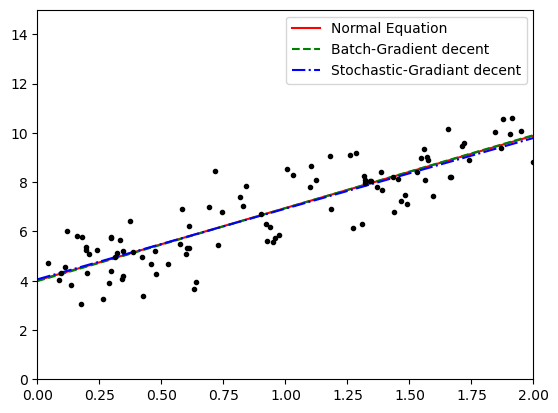

True: intercept = 4, slope = 3
Normal : [4.01324744] [2.93640785]
BGD : [3.98480488] [2.96214223]
SGD : [4.05708763] [2.8679516]


In [20]:
#own test
X = 2 * np.random.rand(100,1)
y = 4 +3 * X + np.random.randn(100,1)

#setting up model
model = MyLinReg()

#new values
X_new = np.array([[0],[2]])

#fitting and predicing using normal eq using normal eq
model.fit(X,y)
y_pred_normal_eq = model.predict(X_new)
normal_weights = model.Weights()

#fitting using BGD and then predicting
theta0 = np.array([[2.0], [1.0]])
model.fitBGD(X,y,theta0)
y_pred_bgd = model.predict(X_new)
BGD_weights = model.Weights()

#fitting using SGF and then predicting
model.fitSGD(X,y,theta0,20)
y_pred_SGD = model.predict(X_new)
SGD_weights = model.Weights()


plt.plot(X_new,y_pred_normal_eq,"r-",label="Normal Equation")
plt.plot(X_new,y_pred_bgd,"g--",label="Batch-Gradient decent")
plt.plot(X_new,y_pred_SGD,"b-.",label="Stochastic-Gradiant decent")
plt.plot(X,y,"k.")
plt.axis([0,2,0,15])
plt.legend()
plt.show()

print("True: intercept = 4, slope = 3")
print("Normal :", normal_weights[0], normal_weights[1])
print("BGD :", BGD_weights[0], BGD_weights[1])
print("SGD :", SGD_weights[0], SGD_weights[1])

**Result analysis**

Both models (GD and SGD) performs well and are both close to the true values of `intercept = 4` and `slope = 3`.

## Describe in text ##

**Describe: Epochs vs iterations:**

**Epoch**: one full pass through the whole training dataset and the parameters are updated based on the calculatied error. So an improvement and adjustment is made for each epoch.

**Iteration**: An iteration occurs each time a batch is processed where the model find the loss, adjusts its parameters and updates its weights based on that loss.

**Epoch vs Iteration**:
In Batch GD, one epoch usually equals one iteration (one update using all data). 
In SGD, one epoch contains `n_samples` iterations (one update per sample)
In mini-batches, one epoch contains `n_samples` / `batch_size` iterations

source: https://www.geeksforgeeks.org/machine-learning/epoch-in-machine-learning/






**Describe: Numerical optimization (GD/SGD) vs closed-form solution**

**Closed-form solution**: solves weigths directly: 

$ \hat{\theta}  = (X^T X)^1 X^T y$

Solve everything using heavy matrix algebra all at once

*Pros*: no learning rate tuning - gets the exact least squares optimum. No hyperparameter tuning. Deterministic.

*Cons*: can be computational expensive for many features (matrix factorization cost), and needs storing/procecesing the full matrix. Not always possible (not linear regression).

**Numerical optimization (GD/SGD)**
Solves the problem analytically by iterative numerical updates.
Uses gradients. Requires learning rate. 
We want to minimize loss function:

$J(\mathbf{w}) = \frac{1}{2} \sum_{i} \left( y^{(i)} - \hat{y}^{(i)} \right)^2$

*Pros*: Scales well to larger datasets. Works when closed-form doesnt. 

*Cons*: Require hyperparameter tuning. May converge slowly. No guarantee of perfect optimum. 

**Analogy/comparison**: 

Say you want to cook an animal. Closed form is like cooking it whole in a large oven. GD/SGD is like cutting it up and cooking them gradually.

If is a small animal like an ant it is fine to cook whole.

If the animal is an elephant it is almost imposible to cook whole and would be a lot easier to cut up and cook gradually (would need a very big oven and a lot of time).


Source: https://sebastianraschka.com/faq/docs/closed-form-vs-gd.html

## Smoke test

In [23]:
import sys
import numpy

### SOME NIFTY HELPER FUNS ###
def isVector(y, expected_n=-1):
    assert isinstance(y, numpy.ndarray), f"expected type 'numpy.array' but got {type(y)}"
    assert y.ndim==1, f"expected y.ndim==1 but got {y.ndim}"
    assert expected_n<0 or expected_n==y.shape[0], f"expected vector of size {expected_n} but got size {y.shape}"
    return True

def isMatrix(X, expected_m=-1, expected_n=-1):
    assert isinstance(X, numpy.ndarray), f"expected type 'numpy.array' but got {type(X)}"
    assert X.ndim==2, f"expected X.ndim==2 but got {X.ndim}"
    assert expected_m<0 or expected_m==X.shape[0], f"expected matrix of size {expected_m}x{expected_n} but got size {X.shape}"
    assert expected_n<0 or expected_n==X.shape[1], f"expected vector of size {expected_m}x{expected_n} but got size {X.shape}"
    return True

def PrintMatrix(x, label="", precision=12, linewidth=60):
    hasFancy = False
    try:
        # NOTE: how does multiple import behave, any performance issues?
        from libitmal.utils import PrintMatrix as FancyPrintMatrix
        hasFancy = True
    except Exception as ex:
        Warn("could not import PrintMatrix from libitmal.utils, defaulting to simple function..")

    if hasFancy:
        FancyPrintMatrix(x, label=label, precision=precision, linewidth=linewidth)
    else:
        # default simple implementation
        print(f"{label}{' ' if len(label)>0 else ''}{x}")

def Col(color):
    hasFancy = False
    try:
        from libitmal.Utils.colors import Col as FancyCol
        hasFancy = True
    except Exception as ex:
        Warn("could not import Col from libitmal.Utils.colors, defaulting to simple function..")

    if hasFancy:
        return FancyCol(color)
    else:
        return ""

def ColEnd():
    hasFancy = False
    try:
        from libitmal.Utils.colors import ColEnd as FancyColEnd
        hasFancy = True
    except Exception as ex:
        Warn("could not import Col from libitmal.Utils.colors, defaulting to simple function..")

    if hasFancy:
        return FancyColEnd()
    else:
        return ""

def PrintOutput(msg, pre_msg, ex=None, color="", filestream=sys.stdout):

    def FormatTxt(txt, linewidth=60, prefix="", replacetabs=True):
        assert isinstance(txt, str)
        assert isinstance(linewidth, int) and linewidth > 0
        assert isinstance(prefix, str)

        if replacetabs:
            txt = txt.replace("\t","    ")

        r = ""
        n = 0
        m = 0
        for i in txt:
            m += 1
            if n >= linewidth:
                if not i.isspace() and m < len(txt) and not txt[m].isspace():
                    r += "\\" # add hypen
                r += "\n" + prefix
                n = 0

            if n == 0 and i.isspace():
                continue # skip leading space

            r += i
            n += 1

            if i == "\n":
                r += prefix
                n = 0

        return r

    col_beg = Col(color)
    col_end = ColEnd()

    prefix = "".ljust(len(pre_msg)) 
    msg = FormatTxt(msg, prefix=prefix)
    
    print(f"{col_beg}{pre_msg}{msg}{col_end}\n", file=filestream)

    if ex is not None:
        #msg += f"\n   EXCEPTION: {ex} ({type(ex)})"
        PrintOutput(str(ex), prefix + "EXCEPTION: ", None, "red", filestream)


def Warn(msg, ex=None):
    PrintOutput(msg, "WARN:  ", ex, "lyellow")


def Err(msg, ex=None):
    PrintOutput(msg, "ERROR: ", ex, "lred" )
    raise Exception(msg) if ex is None else ex


def Info(msg):
    PrintOutput(msg, "INFO:  ", None, "lpurple")


def SimpleAssertInRange(x, expected, eps):
    #assert isinstance(x, numpy.ndarray)
    #assert isinstance(expected, numpy.ndarray)
    #assert x.ndim==1 and expected.ndim==1
    #assert x.shape==expected.shape
    assert eps>0
    assert numpy.allclose(x, expected, eps) # should rtol or atol be set to eps?


def GenerateData():
    X = numpy.array([[8.34044009e-01],[1.44064899e+00],[2.28749635e-04],[6.04665145e-01]])
    y = numpy.array([5.97396028, 7.24897834, 4.86609388, 3.51245674])
    return X, y


def TestMyLinReg():
    X, y = GenerateData()

    try:
        # assume that your regressor class is named 'MyLinReg', please update/change
        regressor = MyLinReg()
    except Exception as ex:
        Err("your regressor has another name, than 'MyLinReg', please change the name in this smoke test", ex)

    try:
        regressor = MyLinReg(max_iter=200)
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ for parameter 'max_iter'", ex)
    try:
        regressor = MyLinReg(eta0=0.01)
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ for parameter 'eta0'", ex)
    try:
        regressor = MyLinReg(verbose=False)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'verbose'", ex)
    try:
        regressor = MyLinReg(tol=1e-3)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'tol'", ex)
    try:
        regressor = MyLinReg(n_iter_no_change=1e-3)
    except Exception as ex:
        Warn("your regressor can not be constructed via the __init_ for parameter 'n_iter_no_change'", ex)

    # create regressor with default hyperparameter values
    # to be used for training, prediction and score..
    try:
        regressor = MyLinReg()
    except Exception as ex:
        Err("your regressor can not be constructed via the __init_ with default parameters", ex)

    try:
        regressor.fit(X, y)
    except Exception as ex:
        Err("your regressor can not fit", ex)

    try:
        y_pred = regressor.predict(X)
        Info(f"y_pred = {y_pred}")
    except Exception as ex:
        Err("your regressor can not predict", ex)

    try:
        score  = regressor.score(X, y)
        Info(f"SCORE = {Col('lblue')}{score}{ColEnd()}")
    except Exception as ex:
        Err("your regressor fails in the score call", ex)


    try:
        w    = None # default
        bias = None # default
        try:
            w = regressor.coef_
            bias = regressor.intercept_
        except Exception as ex:
            w = None
            Warn("your regressor has no coef_/intercept_ atrributes, trying Weights() instead..", ex)
        try:
            if w is None:
                w = regressor.Weights() # maybe a Weigths function is avalible on you model?
                try:
                    assert w.ndim == 1,     "can only handle vector like w's for now"
                    assert w.shape[0] >= 2, "expected length of to be at least 2, that is one bias one coefficient"
                    bias = w[0]
                    w = w[1:]
                except Exception as ex:
                    w = None
                    Err("having a hard time concantenating our bias and coefficients, giving up!", ex)
        except Exception as ex:
            w = None
            Err("your regressor also has no Weights() function, giving up!", ex)
        Info(f"bias         = {bias}")
        Info(f"coefficients = {w}")
    except Exception as ex:
        Err("your regressor fails during extraction of bias and weights (but is a COULD)", ex)

    try:
        from libitmal.utils import PrintMatrix
    except Exception as ex:
        PrintMatrix = SimplePrintMatrix # fall-back
        Warn("could not import PrintMatrix from libitmal.utils, defaulting to simple function..")

    try:
        from libitmal.utils import AssertInRange
    except Exception as ex:
        AssertInRange = SimpleAssertInRange # fall-back
        Warn("could not import AssertInRange from libitmal.utils, defaulting to simple function..")

    try:
        if w is not None:
            if bias is not None:
                w = numpy.concatenate(([bias], w)) # re-concat bias an coefficients, may be incorrect for your implementation!
            
            # TEST VECTOR:
            w_expected = numpy.array([4.046879011698, 1.880121487278])
            
            PrintMatrix(w,          label="       w         =")
            PrintMatrix(w_expected, label="       w_expected=")
            print()
            
            eps = 1E-2 # somewhat big epsilon, allowing some slack..
            AssertInRange(w, w_expected, eps)
            Info("Well, good news, your w and the expected w-vector seem to be very close numerically, so the smoke-test has passed!")
            
            return regressor
        else:
            Warn("cannot test due to missing w information")
    except Exception as ex:
        Err("mini-smoketest on your regressor failed", ex)
    
    return None

Warn("This mini smoke-test may produce false-positives and/or\n false-negatives..")
TestMyLinReg()

print("OK")

WARN:  This mini smoke-test may produce false-positives and/or
       false-negatives..

INFO:  y_pred = [5.61498307 6.75547413 4.04730909 5.18372294]

INFO:  SCORE = 0.49500564295574756

INFO:  bias         = 4.04687901169829

INFO:  coefficients = [1.88012149]

       w         =[4.05 1.88]
       w_expected=[4.05 1.88]

INFO:  Well, good news, your w and the expected w-vector seem to be
       very close numerically, so the smoke-test has passed!

OK


# Lecture 7 - Generalisation

In [26]:
#Resetting all variables 
%reset -f
print("ok")

ok


## Qa) The generalization error
Training error is the error you get on your training data. By increasing capacity, this will lower the training error, since you are overfitting the model to the training data. Hence, you see an increased generalization error when the model is overfit, as the model doesn't perform well on data it has not seen before. On the other hand, your model can have a capacity too low, i.e. not capture the complexity of your data. This is called underfit. In between the overfit/underfit zones is a sweet spot, which is the optimal capacity. Here the generalisation error is at its lowest. Generalisation gap can be thought of the "price" you pay (paid by an increase in error) when you go from known (training) data to general (test) data.

## Qb Learning curves
Firstly. The linear regressor is updated with a loss history function. This is done by intializing an empty list in the fit interfaces of SGD and BGD, and then appendning the loss for each epoch/iteration. The list can be retrieved by calling model.LossHistory()

In [29]:
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np
import matplotlib.pyplot as plt

class MyLinReg(BaseEstimator,RegressorMixin):
    #inherits R2 score from RegressorMixin
    def __init__(self, eta0=0.05, tol=1e-3, max_iter = 100, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0 #stepsize
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def __str__(self):
        return "MyLinReg.__str__(): hi!"

    def fit(self, X, y):    
        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 

        #normal equation implementation
        self.theta = np.linalg.pinv(X) @ y #using the pseudoinverse so it works
        self.intercept_, self.coef_ = self.theta[0], self.theta[1:]

        #loss history
        self.loss_history = [] #resetting loss history
        self.loss_history.append(self.loss(self.theta,X,y)) #storing loss history (redundant feature in this case)
        return self

    def Weights(self):
        return self.theta
        
    def predict(self, X):
        #adding bias term
        n = X.shape[0] #is the same as len(y) but i dont have len(y) here.
        X = np.c_[np.ones((n,1)), X] 
        return X@self.theta

    def loss(self,theta,X,y):
        #based on MSE
        n = len(y)
        #calculation of the sum used in MSE. Vectorized.
        s = (X@theta-y).T@(X@theta-y)

        return (s/n).item() #vectorization gives problems and returns a (1,1) array. .item() converts this to a scalar.
    
    def fitBGD(self,X,y,theta0):
        self.loss_history = [] #resetting loss history

        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        theta = theta0 #intializing

        self.BGDiterations = 0 #for coutning no. iterations
        
        for it in range(self.max_iter): #running until max iterations.
            self.BGDiterations += 1 #counting no of iterations
            
            Nabla_theta = 2/n * X.T@(X@theta-y)
            theta = theta - self.eta0*Nabla_theta #this is with constant learning rate
            
            self.loss_history.append(self.loss(theta,X,y)) #storing loss history. In this case, its per iteration.
            
        self.theta = theta #storing final weights.
        
    def fitSGD(self,X,y,theta0,n_epochs):
        self.loss_history = [] #resetting loss history.  

        n = len(y)
        X = np.c_[np.ones((n,1)), X] #adding bias term
        theta = theta0 #initializing
        def learning_schedule(t):
            t0,t1 = 5,50 #standard værdierne fra bogen idk
            return t0 / (t+t1)
        for epoch in range(n_epochs):
            self.loss_history.append(self.loss(theta,X,y)) #storing loss history per epoch
            for i in range(n):
                ridx = np.random.randint(n) #choosing random index
                xi = X[ridx:ridx+1]
                yi = y[ridx:ridx+1]
                nabla_theta = 2*xi.T@(xi@theta-yi)
                eta = learning_schedule(epoch*n+i) #adaptive learning rate :)
                theta = theta - eta * nabla_theta

        self.theta=theta
        
    ##-------- ADDED LOSS HISTORY FUNCTION ----------##
    def LossHistory(self): 
        return self.loss_history

The loss vs epoch graph is created for the SGD. Additionally, a loss vs iterations for the BGD model.

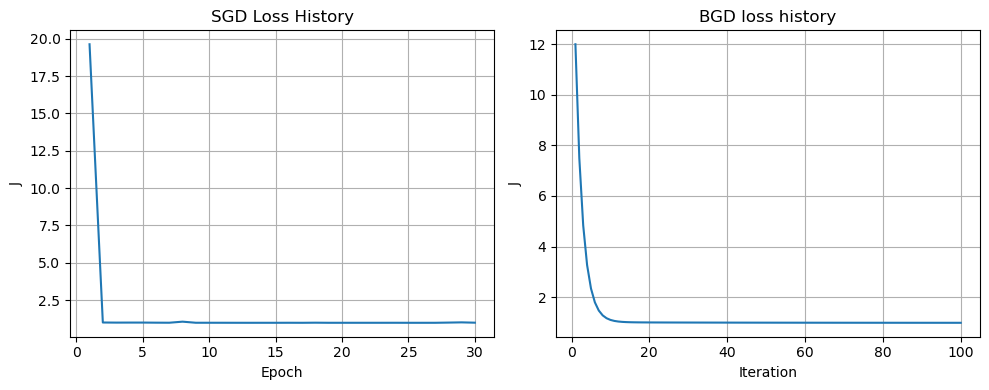

OK


In [30]:
#intansiating two models, both SGD and BGD
r = MyLinReg()
o = MyLinReg()
#generating some random data and fitting it
X = 2 * np.random.rand(100,1)
y = 4 +3 * X + np.random.randn(100,1) #creating some rather noisy data


#fitting using Stochastic Gradiant Descent 
theta0 = np.array([[2.0], [1.0]]) #initial values
n_epochs = 30 #number of epochs
r.fitSGD(X,y,theta0,n_epochs)

#fiting using BGD
o.fitBGD(X,y,theta0)

#extracting loss histories
h1 = r.LossHistory()
h2 = o.LossHistory()

# Plot of J vs. epoch for SGD and J vs iteration for BGD

q1 = np.arange(1,n_epochs+1) #plotting vs no of epochs. Creating a list with values [1,2,...,no_epochs] to plot against.
q2 = np.arange(1,o.BGDiterations+1) #same for no.iterations.

%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#SGD loss history plot
axes[0].plot(q1, h1)
axes[0].set_title("SGD Loss History")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("J")
axes[0].grid()
#BGD loss history plot
axes[1].plot(q2, h2)
axes[1].set_title("BGD loss history")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("J")
axes[1].grid()

plt.tight_layout()
plt.show()

print("OK")

## Qc Early Stopping
Early stopping is to be implemented. Early stopping is a method to regularize iterative learning algorithms such as the implemented BGD and SGD. The idea is to stop training as soon as the validuation error reaches a minimum. This is best explained by the use of the picture below.

<img src="https://itundervisning.ase.au.dk/SWMAL/L07-Generalisation/Figs/early_stopping.png" alt="WARNING: could not get image from server.">

As seen on the Loss vs Epoch graph, the loss function decreases and keeps decreasing on the training set as expected. As the epochs increase, the loss on the training set goes down aswell as the loss on the validation set. After some time, the loss on the validation set starts to increase, which is a clear indicator that the model has started to overfit on the training data. The idea of early stopping is to stop training once the validation error starts increasing too much. In the model above, this would be an actual true minimum, but in real cases one is not always that lucky. In machining learning, some minimum is better than no minimum, and with limitied time, that minimum might be able to perform to requirements. A possible solution to help make sure the model has reached the minimum, is to stop only after the valiation error has been above the minimum for some time, then roll back the model to that specific no. of epochs. In the implementation below, this is not implemented.

In [37]:
## Linear regressor is updated with early stopping functionality.
class MyLinReg(BaseEstimator,RegressorMixin):
    #inherits R2 score from RegressorMixin
    def __init__(self, eta0=0.05, tol=1e-3, max_iter = 100, n_iter_no_change=5, verbose=True):
        self.eta0 = eta0 #stepsize
        self.max_iter = max_iter
        self.tol = tol
        self.n_iter_no_change = n_iter_no_change

    def __str__(self):
        return "MyLinReg.__str__(): hi!"

    def fit(self, X, y):    
        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 

        #normal equation implementation
        self.theta = np.linalg.pinv(X) @ y #using the pseudoinverse so it works
        self.intercept_, self.coef_ = self.theta[0], self.theta[1:]

        #loss history
        self.loss_history = [] #resetting loss history
        self.loss_history.append(self.loss(self.theta,X,y)) #storing loss history (redundant feature in this case)
        return self

    def Weights(self):
        return self.theta
        
    def predict(self, X):
        #adding bias term
        n = X.shape[0] #is the same as len(y) but i dont have len(y) here.
        X = np.c_[np.ones((n,1)), X] 
        return X@self.theta

    def loss(self,theta,X,y):
        #based on MSE
        n = len(y)
        #calculation of the sum used in MSE. Vectorized.
        s = (X@theta-y).T@(X@theta-y)

        return (s/n).item() #vectorization gives problems and returns a (1,1) array. .item() converts this to a scalar.
    
    def fitBGD(self,X,y,theta0,X_val=None, y_val=None,early_stopping=True):
        self.loss_history = [] #resetting loss history
        self.loss_history_val = []
        best_val_loss = np.inf #initializing best loss as infinity, such that the first loss calculated is always better.

        #adding bias term
        n = len(y)
        X = np.c_[np.ones((n,1)), X] 
        theta = theta0 #intializing

        self.BGDiterations = 0 #for coutning no. iterations

        #adding bias term to validation set
        if X_val is not None:
            n_val = X_val.shape[0]
            X_val = np.c_[np.ones((n_val,1)),X_val]
        
        for it in range(self.max_iter): #running until max iterations.
            self.BGDiterations += 1 #counting no of iterations
            Nabla_theta = 2/n * X.T@(X@theta-y)
            theta = theta - self.eta0*Nabla_theta #this is with constant learning rate

            #loss history
            current_loss = self.loss(theta,X,y)
            self.loss_history.append(current_loss) #storing loss history. In this case, its per iteration.

            #calculation of validation history
            if X_val is not None and y_val is not None:
                current_val_loss = self.loss(theta,X_val,y_val) #calculating loss on validation set for current epoch
                self.loss_history_val.append(current_val_loss)

                #early stopping implementation
                if early_stopping: #only triggers if early stopping is true. (it is by default)
                    if best_val_loss - current_val_loss > self.tol:
                        best_val_loss = current_val_loss
                    else:
                        break

            
        self.theta = theta #storing final weights.
        
    def fitSGD(self,X,y,theta0,n_epochs,X_val=None, y_val=None,early_stopping=True):
        self.loss_history = [] #resetting loss history.
        self.loss_history_val = []
        self.SGDtotal_epochs = 0
        best_val_loss = np.inf #initializing best loss as infinity, such that the first loss calculated is always better.
        
        n = len(y)
        X = np.c_[np.ones((n,1)), X] #adding bias term
        theta = theta0 #initializing

        #adding bias term to validation set
        if X_val is not None:
            n_val = X_val.shape[0] 
            X_val = np.c_[np.ones((n_val,1)), X_val] 
        
        def learning_schedule(t):
            t0,t1 = 5,50 #standard værdierne fra bogen idk
            return t0 / (t+t1)
            
        for epoch in range(n_epochs):
            current_loss = self.loss(theta,X,y) #calculating current loss
            self.loss_history.append(current_loss) #storing loss history per epoch
            self.SGDtotal_epochs += 1 #adding count on total epochs
            
            #calculation of validation history
            if X_val is not None and y_val is not None:
                
                current_val_loss = self.loss(theta,X_val,y_val) #calculating loss on validation set for current epoch
                self.loss_history_val.append(current_val_loss)

                if early_stopping: #only triggers if early stopping is true. (it is by default)
                    if best_val_loss - current_val_loss > self.tol:
                        best_val_loss = current_val_loss
                    else:
                        break
            
            for i in range(n):
                ridx = np.random.randint(n) #choosing random index
                xi = X[ridx:ridx+1]
                yi = y[ridx:ridx+1]
                nabla_theta = 2*xi.T@(xi@theta-yi)
                eta = learning_schedule(epoch*n+i) #adaptive learning rate :)
                theta = theta - eta * nabla_theta

        self.theta=theta
        
    def LossHistory(self): 
        return self.loss_history
        
    def LossHistoryValidation(self):
        return self.loss_history_val

Now its time to fit and compare with the old model! Lets start by examplifying using the SGD model. A loss history on the validation set has been implemented in similar fashion to the one for the training set. This is used for plotting purposes and is called using model.LossHistoryValidation.

Final validation loss with early stopping: 5.843942176430777, Final validation loss without early stopping: 6.040446956929294


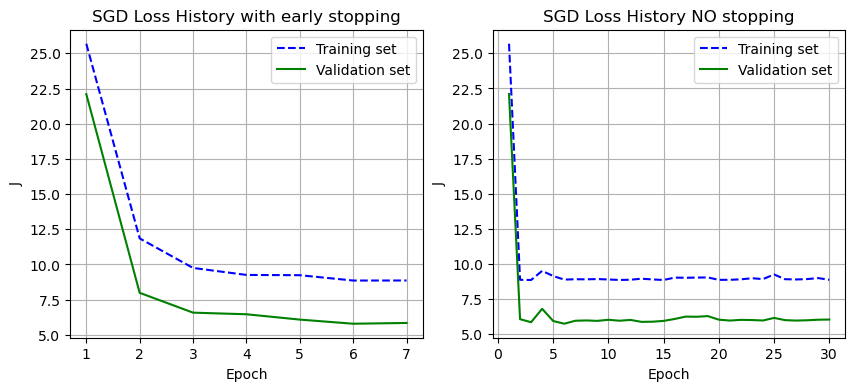

In [35]:
#intansiating two models, one with early stopping and one without it.
r1 = MyLinReg()
r2 = MyLinReg()

#generating some random data and fitting it
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + 3*np.random.randn(100,1) #creating some rather noisy data

#splitting data into train and test (shuffling aswell)
indices = np.arange(len(X))
np.random.shuffle(indices)
X_train, X_valid = X[indices[:80]], X[indices[80:]]
y_train, y_valid = y[indices[:80]], y[indices[80:]]


#fitting using Stochastic Gradiant Descent 
theta0 = np.array([[2.0], [1.0]]) #initial values
n_epochs = 30 #number of epochs

r1.fitSGD(X_train,y_train,theta0,n_epochs,X_valid,y_valid) 
r2.fitSGD(X_train,y_train,theta0,n_epochs,X_valid,y_valid,early_stopping=False)


#extracting loss histories and validation loss histories
h1 = r1.LossHistory()
vh1 = r1.LossHistoryValidation()

h2 = r2.LossHistory()
vh2 = r2.LossHistoryValidation()

# Plot of J vs. epoch for SGD and J vs iteration for BGD
q1 = np.arange(1,r1.SGDtotal_epochs+1) #plotting vs no of epochs. Creating a list with values [1,2,...,no_epochs] to plot against.
q2 = np.arange(1,r2.SGDtotal_epochs+1)
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#SGD loss history plot with early stopping
axes[0].plot(q1, h1,"b--",label="Training set")
axes[0].plot(q1, vh1,"g",label="Validation set")
axes[0].set_title("SGD Loss History with early stopping")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("J")
axes[0].grid()
axes[0].legend()

#SGD loss history plot withOUT early stopping
axes[1].plot(q2, h2,"b--",label="Training set")
axes[1].plot(q2, vh2,"g",label="Validation set")
axes[1].set_title("SGD Loss History NO stopping")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("J")
axes[1].grid()
axes[1].legend()
print(f"Final validation loss with early stopping: {vh1[-1]}, Final validation loss without early stopping: {vh2[-1]}")

As we can see, the number of epochs is reduced drastically! The resulting validation error is roughly the same, although actually a bit better with early stopping. Moving onto batch gradiant descent.

Final validation loss with early stopping: 5.81305808524552, Final validation loss without early stopping: 5.8548876691956675


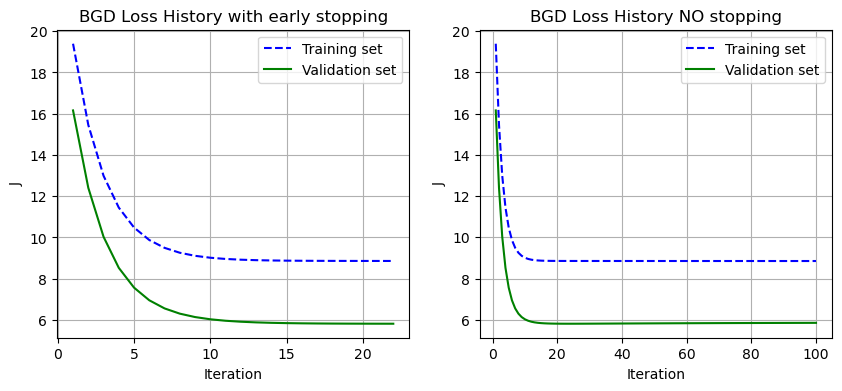

In [36]:
o1 = MyLinReg()
o2 = MyLinReg()

o1.fitBGD(X_train,y_train,theta0,X_valid,y_valid) #using same theta0 as in SGD
o2.fitBGD(X_train,y_train,theta0,X_valid,y_valid,early_stopping=False)

#extracting loss histories and validation loss histories
h1 = o1.LossHistory()
vh1 = o1.LossHistoryValidation()
h2 = o2.LossHistory()
vh2 = o2.LossHistoryValidation()

# Plot of J vs. no. of iterations for BGD
q1 = np.arange(1,o1.BGDiterations+1) 
q2 = np.arange(1,o2.BGDiterations+1)

%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#SGD loss history plot with early stopping
axes[0].plot(q1, h1,"b--",label="Training set")
axes[0].plot(q1, vh1,"g",label="Validation set")
axes[0].set_title("BGD Loss History with early stopping")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("J")
axes[0].grid()
axes[0].legend()

#SGD loss history plot withOUT early stopping
axes[1].plot(q2, h2,"b--",label="Training set")
axes[1].plot(q2, vh2,"g",label="Validation set")
axes[1].set_title("BGD Loss History NO stopping")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("J")
axes[1].grid()
axes[1].legend()

print(f"Final validation loss with early stopping: {vh1[-1]}, Final validation loss without early stopping: {vh2[-1]}")

Similar to what was seen in the SGD a considrabe amount of iterations are saved. In this run, the validation loss reaches a plateau, and starts decreasing so little that the difference in the validation loss between each iteration is so small, that early stopping is triggered.

# Lecture 8 - Regularisation

In [30]:
#Resetting all variables - for en god ordens skyld
%reset -f
print("ok")

ok


## Code from lecture

In [1]:
# Qa..first define some numeric helper functions for the test-vectors..

import numpy as np
from collections.abc import Iterable # fix of missing .abc

def isFloat(x):
    # is there a python single/double float??
    return isinstance(x, float) or isinstance(x, np.float32) or isinstance(x, np.float64)
    # NOT defined on Windows?:   or isinstance(x, np.float128)      

# Checks that a 'float' is 'sane' (original from libitmal)
def CheckFloat(x, checkrange=False, xmin=1E-200, xmax=1E200, verbose=0):
    if verbose>1:
        print(f"CheckFloat({x}, type={type(x)}")
    if isinstance(x, Iterable):
        for i in x:
            CheckFloat(i, checkrange=checkrange, xmin=xmin, xmax=xmax, verbose=verbose)
    else:
        #if (isinstance(x,int)):
        #    print("you gave me an integer, that was ignored")
        #    return
        assert isFloat(x), f"x={x} is not a float/float64/numpy.float32/64/128, but a {type(x)}"
        assert np.isnan(x)==False , "x is NAN"
        assert np.isinf(x)==False , "x is inf"
        assert np.isinf(-x)==False, "x is -inf"
        # NOTE: missing test for denormalized float
        if checkrange:
            z=fabs(x)
            assert z>=xmin, f"abs(x)={z} is smaller that expected min value={xmin}"
            assert z<=xmax, f"abs(x)={z} is larger that expected max value={xmax}"
        if verbose>0:
             print(f"CheckFloat({x}, type={x} => OK")

# Checks that two 'floats' are 'close' (original from libitmal)
def CheckInRange(x, expected, eps=1E-9, autoconverttofloat=True, verbose=0):
    assert eps>=0, "eps is less than zero"
    if autoconverttofloat and (not isFloat(x) or not isFloat(expected) or not isFloat(eps)):
        if verbose>1:
            print(f"notice: autoconverting x={x} to float..")
        return CheckInRange(1.0*x, 1.0*expected, 1.0*eps, False, verbose)
    CheckFloat(x)
    CheckFloat(expected)
    CheckFloat(eps)
    x0 = expected - eps
    x1 = expected + eps
    ok = x>=x0 and x<=x1
    absdiff = np.fabs(x-expected)
    if verbose > 0:
        print(f"CheckInRange(x={x}, expected={expected}, eps={eps}: x in [{x0}; {x1}] => {ok}")
    assert ok, f"x={x} is not within the range [{x0}; {x1}] for eps={eps}, got eps={absdiff}"

print("OK(setup..)")

OK(setup..)


## Qa The Penalty Factor
A function is implemented that can compute the L2 norm of the weights (excluding the bias term). Having this as a penalty factor in the regulizer will force the regressor to minimize the weights.

In [2]:
def Omega(w):
    w = w[1:] # Removing the bias term
    return w @ w.T
 
# weight vector format: [w_0 w_1 .. w_d], ie. elem. 0 is the 'bias'    
w_a = np.array([1., 2., -3.])  
w_b = np.array([1E10, -3E10])
w_c = np.array([0.1, 0.2, -0.3, 0])

p_a = Omega(w_a)
p_b = Omega(w_b)
p_c = Omega(w_c)

print(f"P(w0)={p_a}")
print(f"P(w1)={p_b}")
print(f"P(w2)={p_c}")

# TEST VECTORS
e0 = 2*2+(-3)*(-3)
e1 = 9e+20
e2 = 0.13

CheckInRange(p_a, e0)
CheckInRange(p_b, e1)
CheckInRange(p_c, e2)

print("OK")

P(w0)=13.0
P(w1)=9e+20
P(w2)=0.13
OK


## Qb Explain the Ridge Plot

OK(plot)


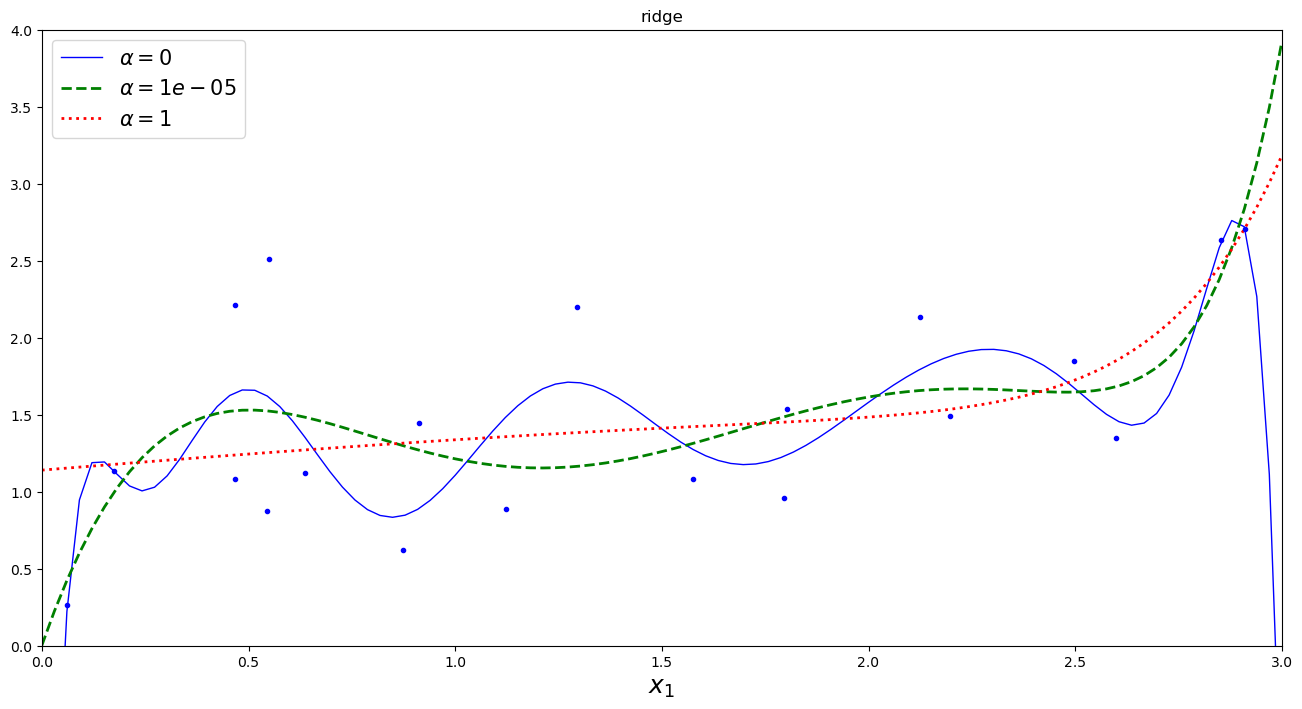

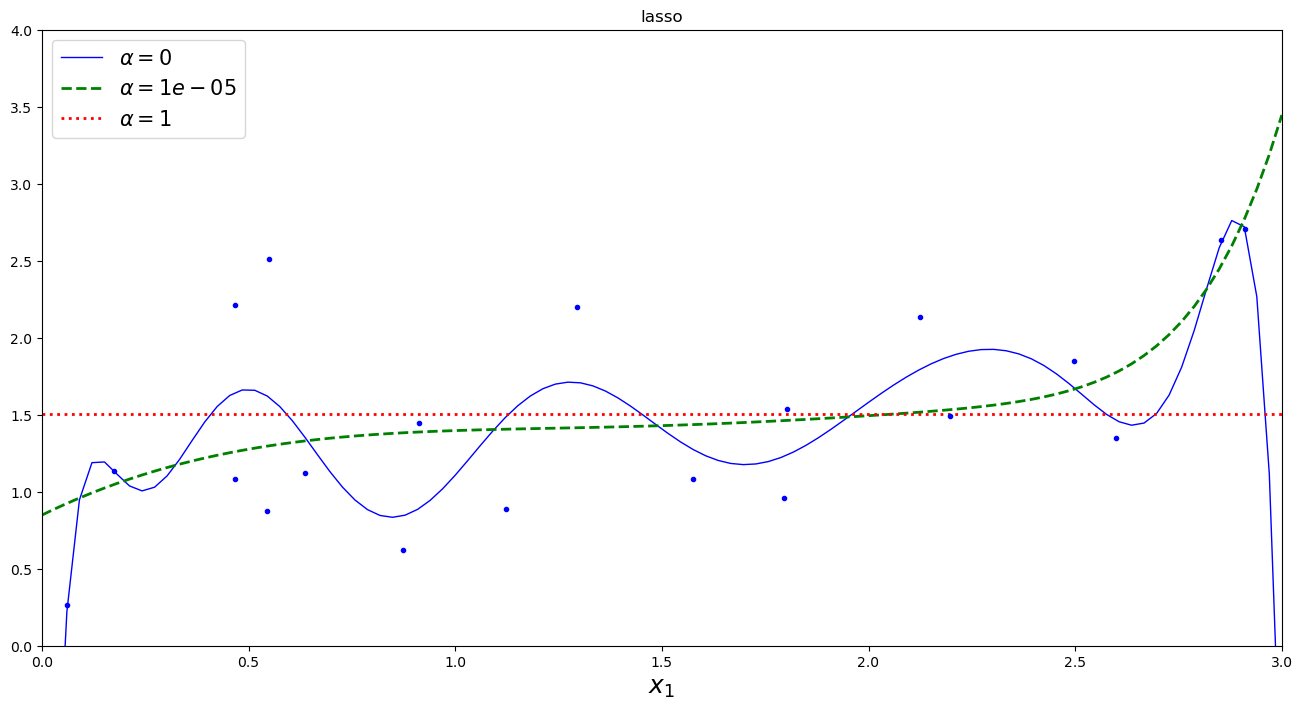

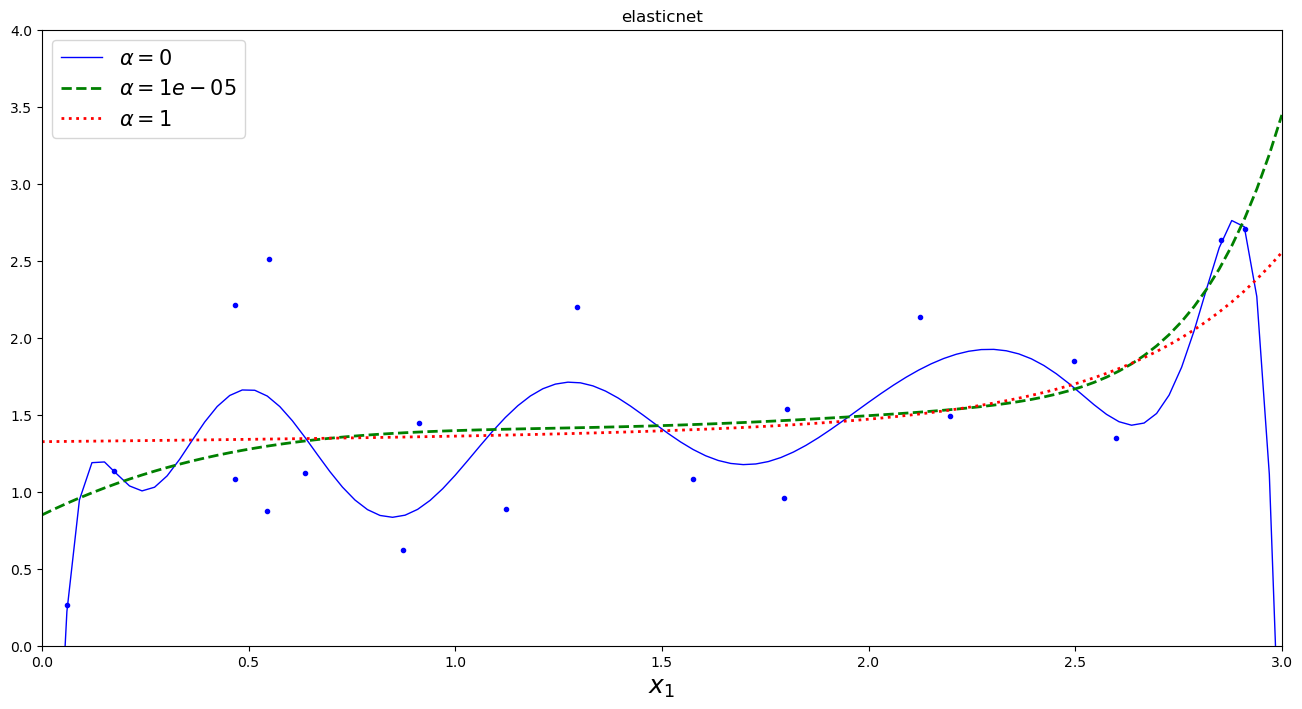

In [42]:
%matplotlib inline

from sklearn.linear_model import LinearRegression, SGDRegressor, Ridge, ElasticNet, Lasso

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Just to get rid of the warning message about convergence.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

def FitAndPlotModel(name, model_class, X, X_new, y, **model_kargs):
    plt.figure(figsize=(16,8))
    
    alphas=(0, 10**-5, 1) 
    random_state=42
    
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        #print(model_kargs)
        model = model_class(alpha, **model_kargs) if alpha > 0 else LinearRegression()
        model_pipe = Pipeline([
                ("poly_features", PolynomialFeatures(degree=12, include_bias=False)),
                ("std_scaler", StandardScaler()),
                ("regul_reg", model),
            ])
            
        model_pipe.fit(X, y)
        y_new_regul = model_pipe.predict(X_new)
        
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha = {}$".format(alpha))
    
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.title(name)
    plt.axis([0, 3, 0, 4])

def GenerateData():
    np.random.seed(42)
    m = 20
    X = 3 * np.random.rand(m, 1)
    y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
    X_new = np.linspace(0, 3, 100).reshape(100, 1)
    return X, X_new, y
    
X, X_new, y = GenerateData()

FitAndPlotModel('ridge',      Ridge,        X, X_new, y)
FitAndPlotModel('lasso',      Lasso,        X, X_new, y)
FitAndPlotModel('elasticnet', ElasticNet,   X, X_new, y, l1_ratio=0.1)

warnings.filterwarnings("ignore", category=ConvergenceWarning)

print("OK(plot)")

### ANSWER

Increasing $\alpha$ seems to lower the order of polynomial fit. For ridge, it tends to become a line through the mean of the data. For lasso, the line tends to become straight horizontal. The elaticnet combines the two, and here we still see the line follow the mean, but not so much as in ridge.

## Qc Explain the Ridge, Lasso and ElasticNet Regularization Methods

While Rigde relies on the l2 norm, Lasso regulizes with the l1 norm. The ElasticNet regularization is a combinetion of the two, where a hyperparameter called the mix ratio, $r$, determines how much the Ridge and Lasso should influence the loss function. If $r=0$ then ElasticNet is equal to Ridge and if $r=1$ then ElasticNet is equal to Lasso. Equal for all of the is that a hyperparameter $\alpha$ has to be set. If $\alpha$ is large, then the model is heavily penaltized by the Ridge/Lasso/ElasticNet and the weights will tend to get very small, maybe even too small (underfitting). On the other hand, if $\alpha$ is low, then the penaltization from Ridge/Lasso/ElasticNet is low, and the weights are not really regularized.

# Lecture 9 - Data Analysis

## Description of dataset

**Provide a short conceptual project description of your idea for the O4 project.**

In a world with growing demand for electricity, it is becoming increasingly important to predict electricity prices. This allows consumers to charge their electric cars, do the laundry and much more in low hours and eventually save money. For our project, we will try to predict the future price of electricity based on current production, price weather, and forecasted weather. This will be done by training and implementing a suitable ML algorithm.

**Describe your chosen dataset with a brief explanation of the background and where you obtained the data from.**

The dataset contains hourly information about electricity in Spain in the years 2014-2019. The information is collected from 5 large cities in Spain that are geographically well distributed across the country. The dataset has been collected from kaggle. The contributor on kaggle has retrieved the consumption and generation data directly from ENTSOE which is a portal for Transmission Service Operator data. The Settlement prices have been obtained directly from Red Electric Espana. The weather data has been retrieved from the Open Weather API. 

The dataset can be found here: https://www.kaggle.com/datasets/nicholasjhana/energy-consumption-generation-prices-and-weather

**Describe the data—i.e., which features, number of samples, target values, possible errors/uncertainties, etc.**

The dataset contains 2 different csv-files. 1 called energy_dataset and another called weather_features. The energy dataset contains 35.064 samples and 29 features. The weather dataset contains 178.396 samples and 17 features. Every sample in both datasets represents 1 hour of data. 

Examples of features in the energy dataset are the amount of energy generated for different energytypes (gas, coal, oil, geothermal etc.), total load, time and price. The weather dataset contains the observed weather for 5 different cities in Spain.

There are some uncertainties in the dataset. Especially in the energy dataset there is several missing values. The weather dataset contains hourly weather conditions for 5 different cities, which might give rise to problems as to whether certain cities influence the price more than others.

**Explain how you intend to use the dataset—for example, do you want to use it to predict something specific, perform a regression or classification, or similar?**

Given the dataset we primarily see two options to work towards:

*“Current” price prediction:*
To predict the hourly electricity price given all the data (both weather_features and energy_dataset). This can be trained against the actual dataset and hopefully come close given all the information

*“Day in advance” price prediction:*
To predict the hourly electricity price 24 hours ahead of time and compare it to a benchmark set by the TSO. Here it is important to only use available information, at the time of the prediction, so mainly the energy forecast would be used here. 


## Data Analysis

In [13]:
#Resetting all variables - for en god ordens skyld
%reset -f
print("ok")

ok


First the two datasets (weather and energy) are loaded from the csv files with pandas.

In [4]:
import pandas as pd

# Load the file
df_e = pd.read_csv('energy_dataset.csv')
df_w= pd.read_csv('weather_features.csv')

# View the first 5 rows of the energy dataset
df_e.head()

,time,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
0,2015-01-01 00:00:00+01:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,...,196.0,0.0,6378.0,17.0,NaN,6436.0,26118.0,25385.0,50.10,65.41
1,2015-01-01 01:00:00+01:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,...,195.0,0.0,5890.0,16.0,NaN,5856.0,24934.0,24382.0,48.10,64.92
2,2015-01-01 02:00:00+01:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,...,196.0,0.0,5461.0,8.0,NaN,5454.0,23515.0,22734.0,47.33,64.48
3,2015-01-01 03:00:00+01:00,438.0,254.0,0.0,4314.0,4131.0,160.0,0.0,0.0,0.0,...,191.0,0.0,5238.0,2.0,NaN,5151.0,22642.0,21286.0,42.27,59.32
4,2015-01-01 04:00:00+01:00,428.0,187.0,0.0,4130.0,3840.0,156.0,0.0,0.0,0.0,...,189.0,0.0,4935.0,9.0,NaN,4861.0,21785.0,20264.0,38.41,56.04


Examining the data type and non-null counts.

In [5]:
df_e.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 29 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   time                                         35064 non-null  object 
 1   generation biomass                           35045 non-null  float64
 2   generation fossil brown coal/lignite         35046 non-null  float64
 3   generation fossil coal-derived gas           35046 non-null  float64
 4   generation fossil gas                        35046 non-null  float64
 5   generation fossil hard coal                  35046 non-null  float64
 6   generation fossil oil                        35045 non-null  float64
 7   generation fossil oil shale                  35046 non-null  float64
 8   generation fossil peat                       35046 non-null  float64
 9   generation geothermal                        35046 non-null  float64
 10

Looking at the mean, standard deviation, etc.:

In [6]:
df_e.describe()

,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage aggregated,...,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind offshore eday ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
count,35045.000000,35046.000000,35046.0,35046.000000,35046.000000,35045.000000,35046.0,35046.0,35046.0,0.0,...,35045.000000,35046.0,35046.000000,35064.000000,0.0,35064.000000,35064.000000,35028.000000,35064.000000,35064.000000
mean,383.513540,448.059208,0.0,5622.737488,4256.065742,298.319789,0.0,0.0,0.0,NaN,...,269.452133,0.0,5464.479769,1439.066735,NaN,5471.216689,28712.129962,28696.939905,49.874341,57.884023
std,85.353943,354.568590,0.0,2201.830478,1961.601013,52.520673,0.0,0.0,0.0,NaN,...,50.195536,0.0,3213.691587,1677.703355,NaN,3176.312853,4594.100854,4574.987950,14.618900,14.204083
min,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,NaN,...,0.000000,0.0,0.000000,0.000000,NaN,237.000000,18105.000000,18041.000000,2.060000,9.330000
25%,333.000000,0.000000,0.0,4126.000000,2527.000000,263.000000,0.0,0.0,0.0,NaN,...,240.000000,0.0,2933.000000,69.000000,NaN,2979.000000,24793.750000,24807.750000,41.490000,49.347500
50%,367.000000,509.000000,0.0,4969.000000,4474.000000,300.000000,0.0,0.0,0.0,NaN,...,279.000000,0.0,4849.000000,576.000000,NaN,4855.000000,28906.000000,28901.000000,50.520000,58.020000
75%,433.000000,757.000000,0.0,6429.000000,5838.750000,330.000000,0.0,0.0,0.0,NaN,...,310.000000,0.0,7398.000000,2636.000000,NaN,7353.000000,32263.250000,32192.000000,60.530000,68.010000
max,592.000000,999.000000,0.0,20034.000000,8359.000000,449.000000,0.0,0.0,0.0,NaN,...,357.000000,0.0,17436.000000,5836.000000,NaN,17430.000000,41390.000000,41015.000000,101.990000,116.800000


When looking at the data we see some of the features only contain zero values. These are not usefull for anything:

'generation fossil coal-derived gas',

'generation fossil oil shale',

'generation fossil peat',

'generation geothermal',

'generation hydro pumped storage aggregated',

'generation marine',

'generation wind offshore',

'forecast wind offshore eday ahead'

Then the two datasets are visuallised with histograms. 

**Energy dataset:**

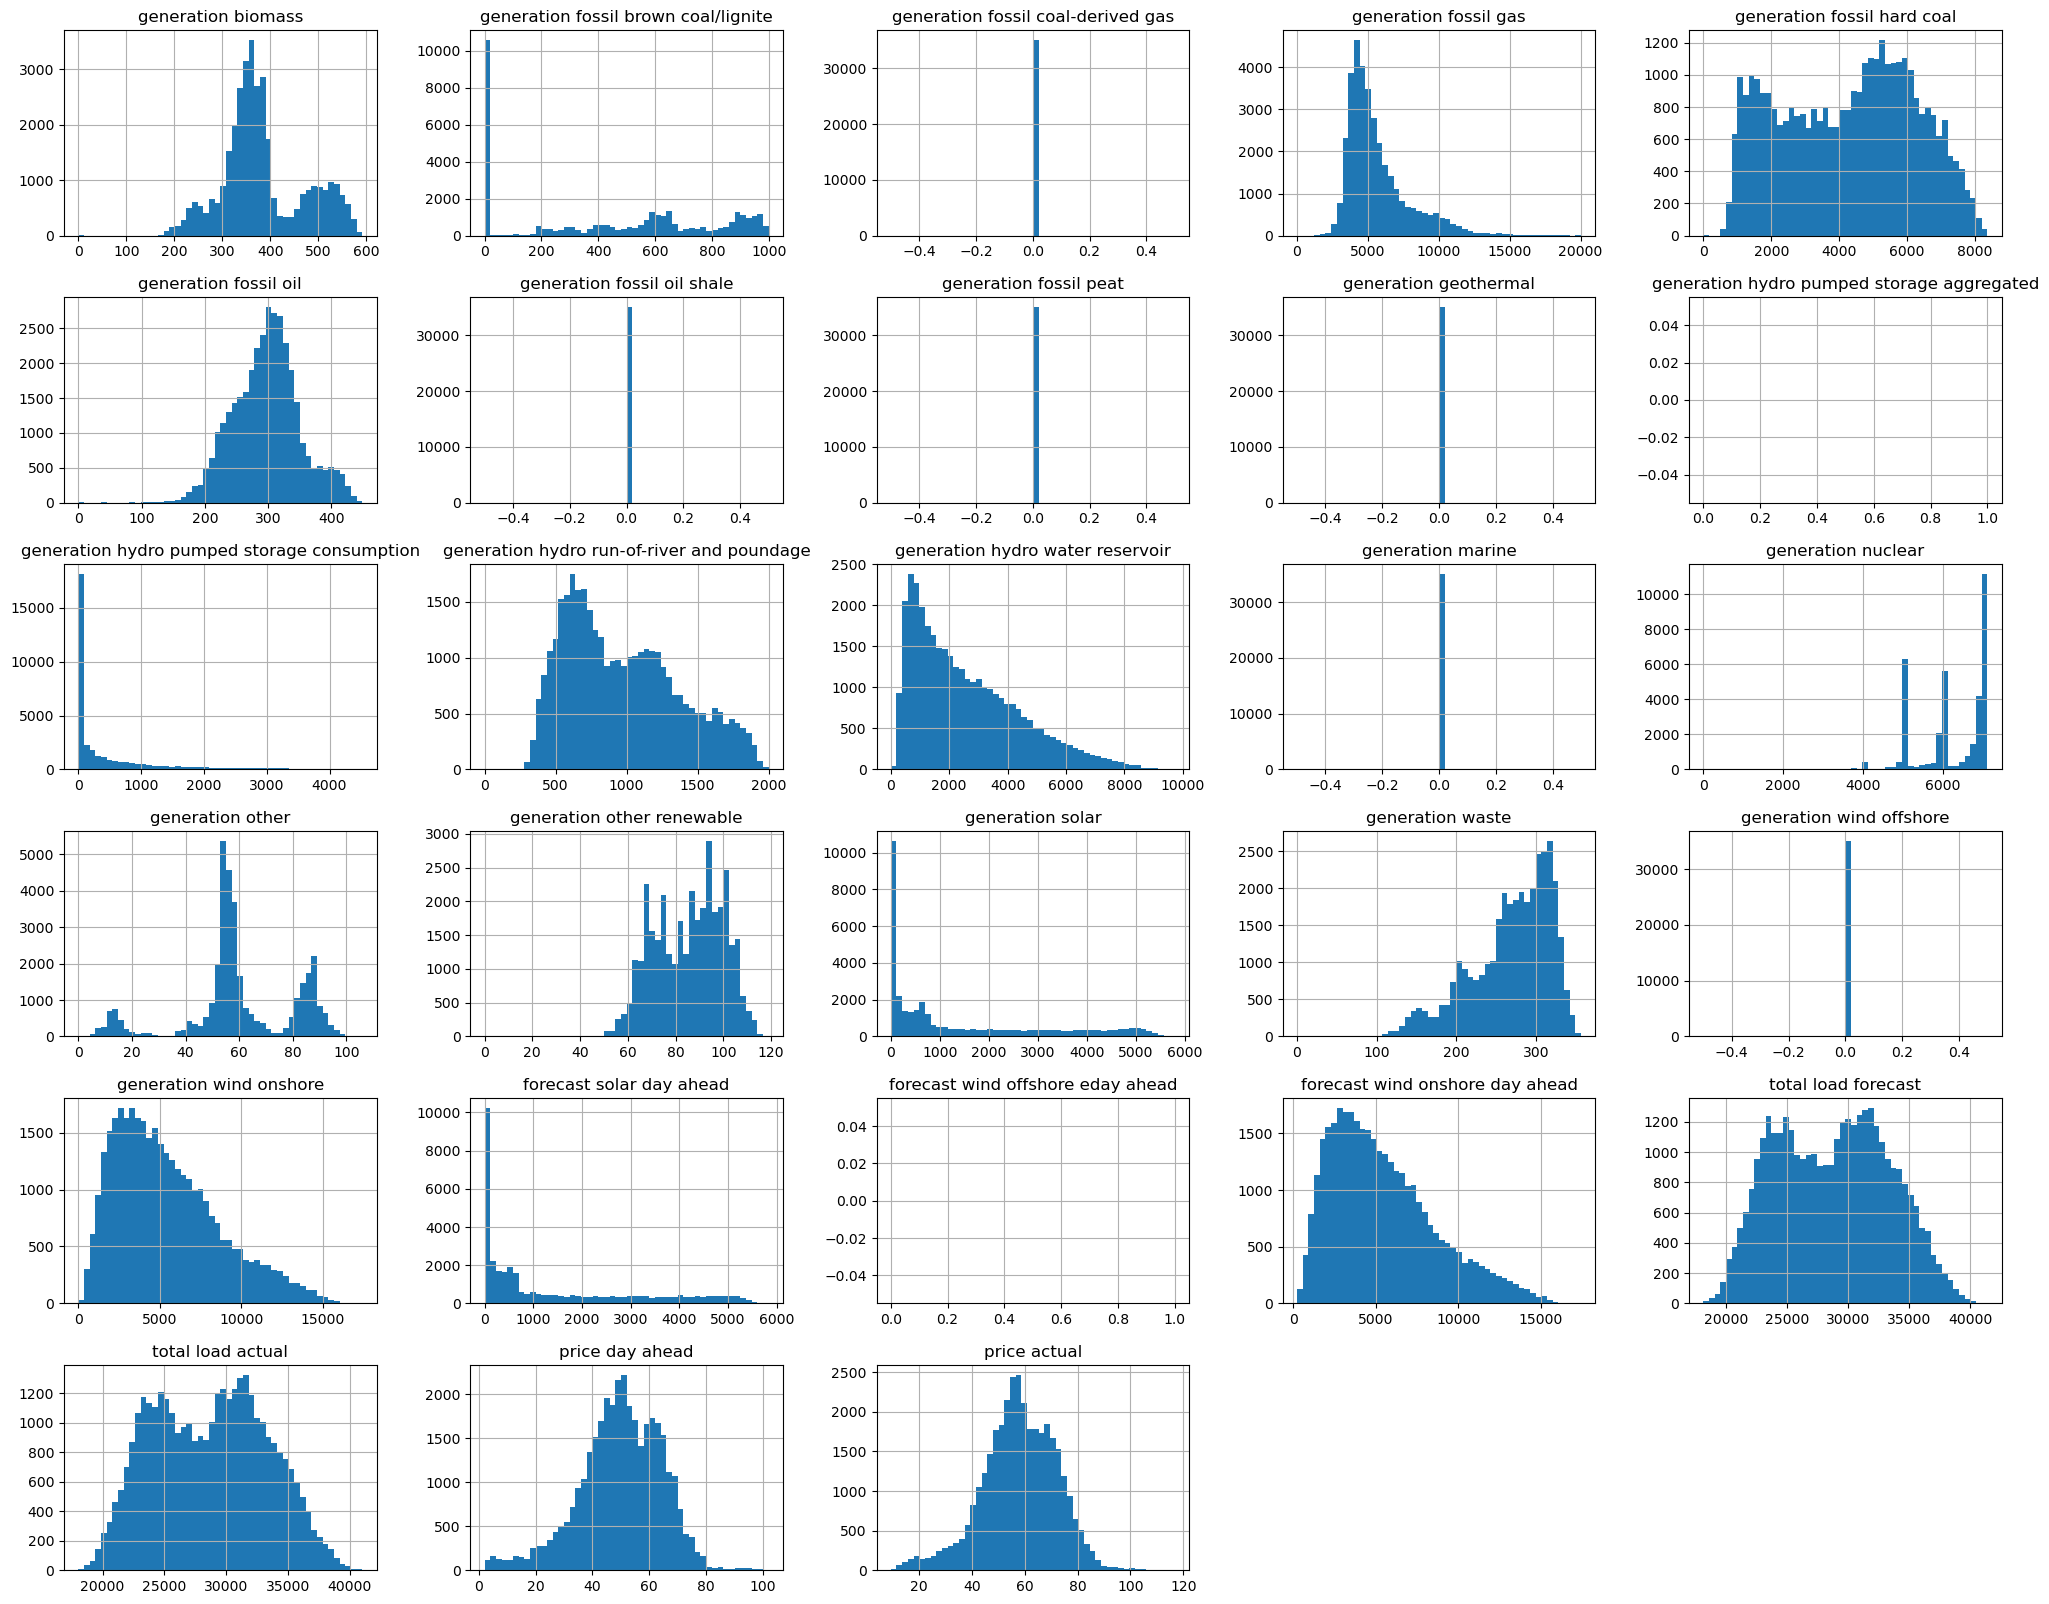

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
df_e.hist(bins=50, figsize=(25,20))
plt.show()

As mentioned, some of the data just contains zeros. 
For the rest the data seem to be rather smoothly distributed without having in depth knowlegde of how energy generation curves looks.
The nuclear generation looks to have some values more common than others. This is actually something nuclear power plants often aim for (e.g to be at certain fixed values) and hence the histogram actually make sense (even though it does not look to be smoothly distributed).

**Weather** 

Next is the histogram for the weather data:

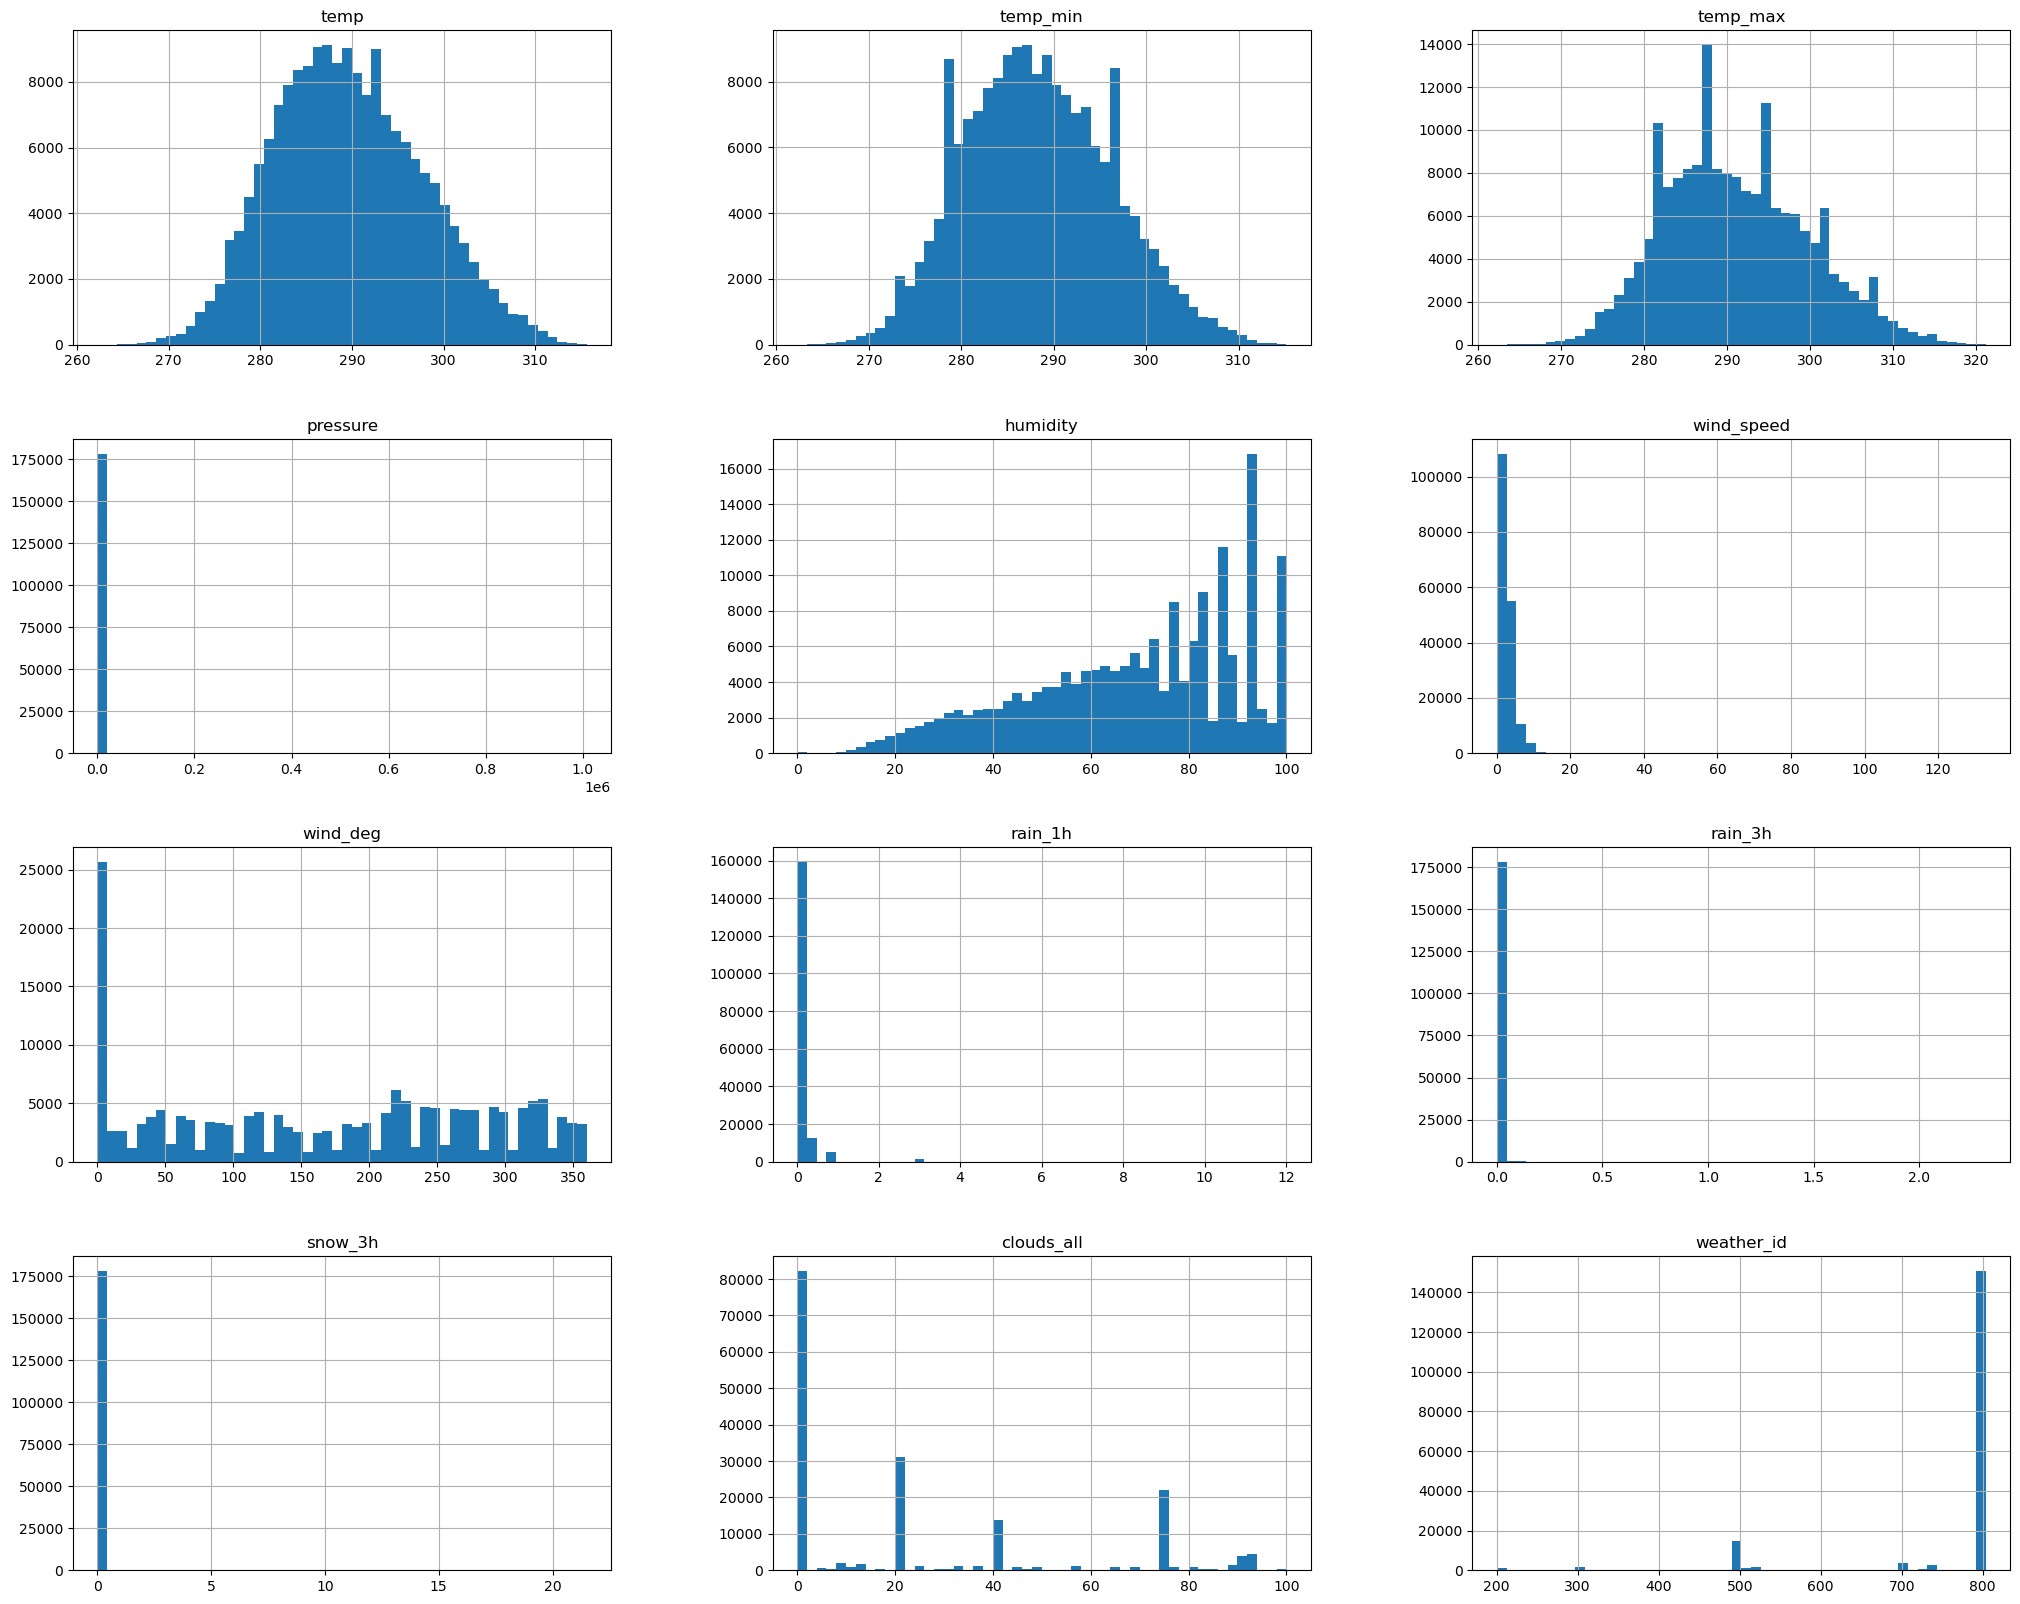

In [9]:
df_w.hist(bins=50, figsize=(25,20))
plt.show()

When assessing the histogram some things stand out. 

**temp**

The min- and max temperature have some certain values having a lot more datapoints. It seems a bit odd that they are not smoothly curves.

**pressure and wind**

Pressure and wind seem to have some very large values and will be looked at in depth later.

**humidity**

Humidity also seem to look a bit odd - especially nearing humidity of 100 percent it seem to have an irregular pattern.

### Looking for outliers ##
There are several outliers in the data. The data in question is printed below. Here is a walkthrough of some of the features:

### Weather data ##
First the wheater data is inspected. 

**temp , temp_min , temp_max** 

The lowest temperature of 262 K (-11 degrees celcius) seems reasonable as the coldest measured temperature in spain over several years. 
the highest temperature of 321 K (48 degrees celcius) also seems reasonable as the highest tempeterature.

**pressure**

For pressure there seem to be several outliers. 

For the largest values there are 45 values at least an order of magnitude larger than the others. It could be a faulty sensor or that the unit is different for these data points. It is not obvovious what is wrong, so they are set to be NaN.

For the smallest values there are also obvious outliers (0 , 0 , 594) these are set to NaN.

For remaining data for pressure is between 918-1087 hPa. The largest and smallest values seem unlikely but its very though to make a cut, so for now we dont do anything else with the pressure data.

**wind_speed**

When looking for outliers it becomes evident some of the features may contain mistakes in the data. For instance the wind speed of 133 m/s on 11th may 2017 is above the highest recorded wind speed in history and is clearly wrong. Anything above 50 m/s we expect to be outliers.
They are replaced with NaN.

In [10]:
print("5 lowest temperatures measured [K]\n" , df_w["temp_min"].nsmallest(5))
print("5 highest temperatures measured [K]\n" , df_w["temp_max"].nlargest(5))
print("46 highest pressure. First collumn is row indicies. Second collumn is values [hPa]\n" , df_w["pressure"].nlargest(46))
print("6 smallest pressure values. First collumn is row indicies. Second collumn is values [hPa]\n" , df_w["pressure"].nsmallest(6))
print("10 largest wind speeds recorded [m/s]" , df_w["wind_speed"].nlargest(10))

5 lowest temperatures measured [K]
 108645    262.240
36063     264.132
89431     264.150
89432     264.150
89433     264.150
Name: temp_min, dtype: float64
5 highest temperatures measured [K]
 147482    321.15
147483    321.15
147484    321.15
147269    320.15
147388    320.15
Name: temp_max, dtype: float64
46 highest pressure. First collumn is row indicies. Second collumn is values [hPa]
 108589    1008371
108619    1002881
108618    1002241
108596    1001781
108597    1001501
108598    1000951
108572     102153
108573     102132
108574     102075
108575     101983
108576     101921
108577     101756
108579     101574
108584     101338
108585     101324
108586     101162
108587     101061
108588     101007
108592     100477
108593     100390
108594     100326
108622     100304
108620     100286
108623     100242
108595     100240
108617     100211
108625     100164
108616     100146
108615     100108
108599     100078
108612     100064
108611     100044
108610     100025
108609     1

# Lecture 10 - Pipelines

## Code from lecture

X.shape=(29, 1),  y.shape=(29,)
OK
The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..

lin.reg.score(X, y)=0.73
    MLP.score(X, y)=-21611.33

OK


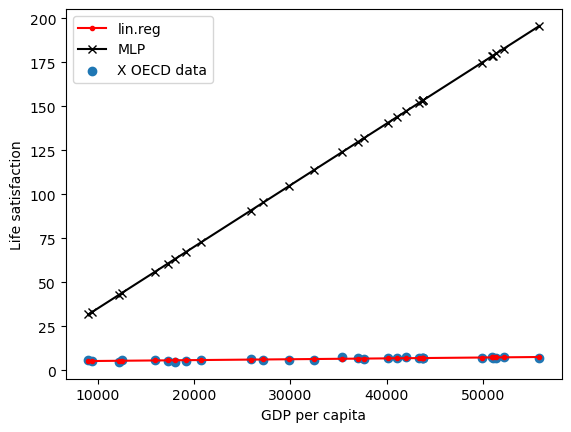

In [45]:
%matplotlib inline

import sys
import pickle
import numpy as np
import matplotlib.pyplot as plt

from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def LoadDataFromL01():
    filename = "Data/itmal_l01_data.pkl"
    with open(f"{filename}", "rb") as f:
        (X, y) = pickle.load(f)
        return X, y

X, y = LoadDataFromL01()

print(f"X.shape={X.shape},  y.shape={y.shape}")

assert X.shape[0] == y.shape[0]
assert X.ndim == 2
assert y.ndim == 1  # did a y.ravel() before saving to picke file
assert X.shape[0] == 29

# re-create plot data (not stored in the Pickel file)
m = np.linspace(0, 60000, 1000)
M = np.empty([m.shape[0], 1])
M[:, 0] = m

print("OK")

# Setup the MLP and lin. regression again..

def isNumpyData(t: np.ndarray, expected_ndim: int):
    assert isinstance(expected_ndim, int), f"input parameter 'expected_ndim' is not an integer but a '{type(expected_ndim)}'"
    assert expected_ndim>=0, f"expected input parameter 'expected_ndim' to be >=0, got {expected_ndim}"
    if t is None:
        print("input parameter 't' is None", file=sys.stderr)
        return False
    if not isinstance(t, np.ndarray):
        print("excepted numpy.ndarray got type '{type(t)}'", file=sys.stderr)
        return False
    if not t.ndim==expected_ndim:
        print("expected ndim={expected_ndim} but found {t.ndim}", file=sys.stderr)
        return False
    return True

def PlotModels(model1, model2, X: np.ndarray, y: np.ndarray, name_model1: str, name_model2: str):
    
    # NOTE: local function is such a nifty feature of Python!
    def CalcPredAndScore(model, X: np.ndarray, y: np.ndarray,):
        assert isNumpyData(X, 2) and isNumpyData(y, 1) and X.shape[0]==y.shape[0]
        y_pred_model = model.predict(X)
        score_model = r2_score(y, y_pred_model) # call r2
        return y_pred_model, score_model    

    assert isinstance(name_model1, str) and isinstance(name_model2, str)

    y_pred_model1, score_model1 = CalcPredAndScore(model1, X, y)
    y_pred_model2, score_model2 = CalcPredAndScore(model2, X, y)

    plt.plot(X, y_pred_model1, "r.-")
    plt.plot(X, y_pred_model2, "kx-")
    plt.scatter(X, y)
    plt.xlabel("GDP per capita")
    plt.ylabel("Life satisfaction")
    plt.legend([name_model1, name_model2, "X OECD data"])

    l = max(len(name_model1), len(name_model2))
    
    print(f"{(name_model1).rjust(l)}.score(X, y)={score_model1:0.2f}")
    print(f"{(name_model2).rjust(l)}.score(X, y)={score_model2:0.2f}")

# lets make a linear and MLP regressor and redo the plots
mlp = MLPRegressor(hidden_layer_sizes=(10, ),
                   solver='adam',
                   activation='relu',
                   tol=1E-5,
                   max_iter=100000,
                   verbose=False)
linreg = LinearRegression()

mlp.fit(X, y)
linreg.fit(X, y)

print("The MLP may mis-fit the data, seen in the, sometimes, bad R^2 score..\n")
PlotModels(linreg, mlp, X, y, "lin.reg", "MLP")
print("\nOK")

## Qa - Minmax scaler

The score on scaled data: 0.7272759355278957


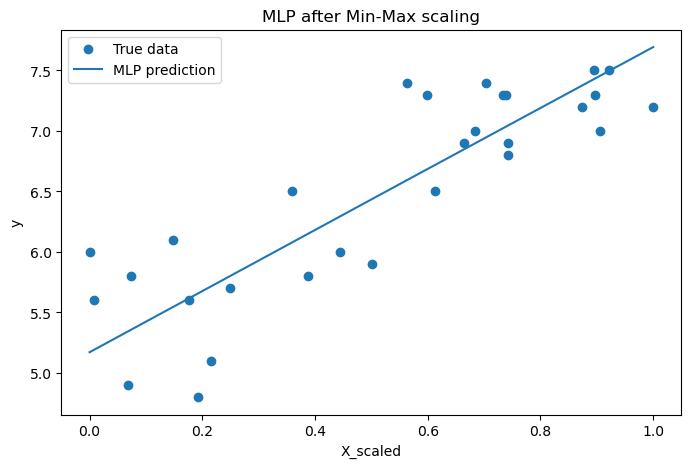

In [46]:
# We will create a function the takes the dataset as input and scales the data using min max
import numpy as np

def MinMaxScaler(X):
    X = np.asarray(X)
    X_min = np.min(X,axis=0) # Taking the min of each column
    X_max = np.max(X,axis=0) # Taking the max of each column
    return (X - X_min) / (X_max - X_min)

# Scaling the data
X_scaled = MinMaxScaler(X)

# Retraining on scaled data
mlp.fit(X_scaled, y)
score = mlp.score(X_scaled, y)
print("The score on scaled data:",score)

y_pred = mlp.predict(X_scaled)

# Replotting
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], y, label="True data")
plt.plot(X_scaled[:, 0], y_pred, label="MLP prediction")
plt.xlabel("X_scaled")
plt.ylabel("y")
plt.title("MLP after Min-Max scaling")
plt.legend()
plt.show()

## Qb) Scikit-learn Pipelines

   lin.reg.score(X, y)=0.73
MLP+MinMax.score(X, y)=0.73


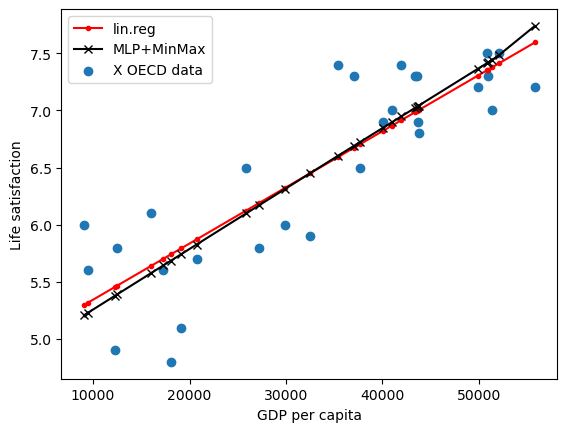

In [47]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline

# Constructing pipelines
# Minmax pipeline
pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', mlp)
])

lin_pipe = Pipeline([
    ('scaler', MinMaxScaler()),
    ('linreg', LinearRegression())
])

# fitting the data 
pipe.fit(X, y)
lin_pipe.fit(X, y)

PlotModels(lin_pipe, pipe, X, y, "lin.reg", "MLP+MinMax")

## Qc) Outliers and the Min-max Scaler vs. the Standard Scaler

The problem with the min-max scaler is that if the data has outliers that lie far away from the rest of the data, using the min-max scaler will crush the properties of the data as it has to scale the data so that the outlier also comes within the range of 0:1. To sum up all the important data would exist within a tiny interval near 0 and the outlier would be near 1.

As seen in the output below the standard scaler has a better score, but from the plotting its clear that the standard scaler is more sensitive to noise.

MLP+standard.score(X, y)=0.75
  MLP+MinMax.score(X, y)=0.73


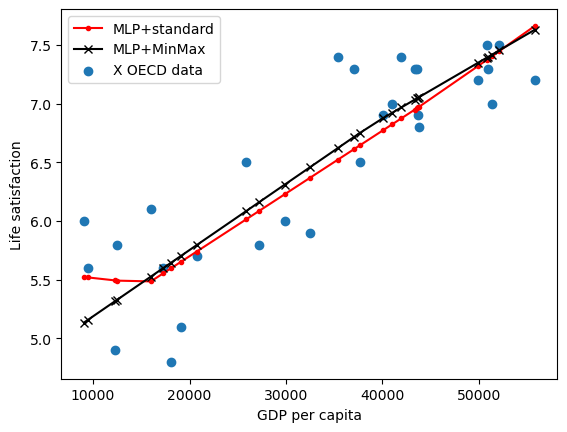

In [48]:
from sklearn.preprocessing import StandardScaler
# Constructing 
# Minmax regressor
mlp_minmax = MLPRegressor(hidden_layer_sizes=(10,),
                          solver='adam',
                          activation='relu',
                          tol=1E-5,
                          max_iter=100000,
                          verbose = False)
# Standard regressor
mlp_standard = MLPRegressor(hidden_layer_sizes=(10,),
                            solver='adam',
                            activation='relu',
                            tol=1E-5,
                            max_iter=100000,
                            verbose = False)

# constructing pipelines
pipe_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('mlp', mlp_minmax)
])

pipe_standard = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', mlp_standard)
])

pipe_minmax.fit(X, y) # Using min-max
pipe_standard.fit(X, y) # Using standard-scaler

PlotModels(pipe_standard, pipe_minmax, X, y, "MLP+standard", "MLP+MinMax")

## Qd) Modify the MLP Hyperparameters

The scores are generally bad as the data might be too small to use cross-validation. It can be concluded that 5-10 neurons should be enough for this dataset, the model performs much better with early stopping and the adam solver is the best.

In [49]:
from sklearn.model_selection import cross_val_score

# Function that constructs a pipeline with the hyperparameters that are desired
def test_mlp(neurons=10, early=False, activation="relu", solver="adam"):
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(neurons,),
            early_stopping=early,
            activation=activation,
            solver=solver,
            tol=1E-5,
            max_iter=20000,
            random_state=42
        ))
    ])
    
    scores = cross_val_score(pipe, X, y, cv=5, scoring="r2") # Using cross validation so the model evaluates on unseen data
    return scores.mean()

print("Scores with different neuron numbers")
for h in [1, 2, 3, 5, 8, 10, 15]:
    print(h, test_mlp(neurons=h))

# Trying early stopping
print("Early stopping with neurons=5")
print("No early stopping:", test_mlp(neurons=5, early=False))
print("With early stopping:", test_mlp(neurons=5, early=True))

# Trying different activations
for act in ["relu", "tanh", "logistic"]:
    print(act, test_mlp(neurons=5, activation=act))

# Trying different solvers
for solver in ["adam", "sgd", "lbfgs"]:
    print(solver, test_mlp(neurons=5, solver=solver))

Scores with different neuron numbers
1 -1.1071993302156735
2 -11.72137017150001
3 -4.604422124813985
5 -1.9255267297337089
8 -4.5130628276056575
10 -4.821201223228285
15 -2.7185339793401284
Early stopping with neurons=5
No early stopping: -1.9255267297337089
With early stopping: -20.951864012809377
relu -1.9255267297337089
tanh -0.7351779948333739
logistic -1.5135876941942328
adam -1.9255267297337089
sgd -28.194829037315536
lbfgs -3.559248316589733


## Conclusion
Across these exercises we found that scaling is essential when dealing with MLPs. Pipelines can be used to implement the preprossesing before fitting in a clean way. The 2 different scaling methods were implemented and it was found that minmax was sensitive to outliers, whereas the standard scaler was more sensitive to noise. Furthermore the different hyperparameters of the MLP were tested.

# Lecture 12 - MLP with Keras

## Code from lecture

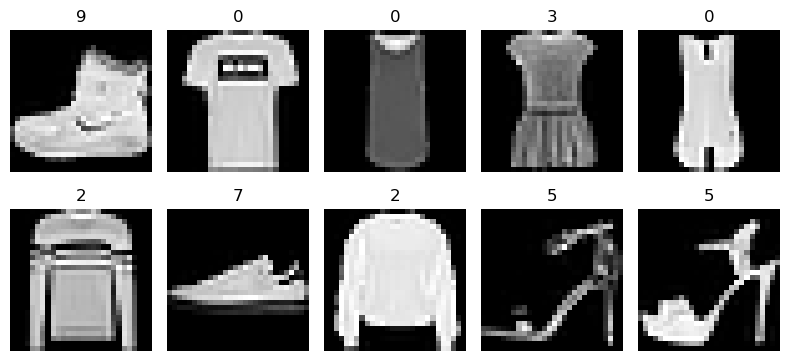

In [50]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from time import strftime

(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# Split training data into training and vvalidation sets - skiped since we are using validation_split

#X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
#y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

# Normalize pixel values to range [0, 1]
X_test = X_test / 255.0
X_train = X_train_full / 255.0
y_train = y_train_full

plt.figure(figsize=(8, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(y_train[i])
    plt.axis("off")
    plt.tight_layout()
plt.show()

## T2a)

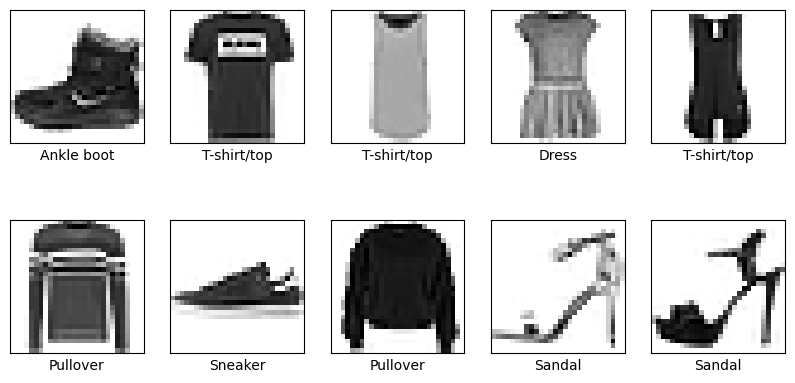

In [52]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]
# TODO: add your code here..
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    
    # Replace numeric label with class name
    plt.xlabel(class_names[y_train[i]])

plt.show()

## Code from lecture

C:\Users\kaspe\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7067 - loss: 0.9211 - val_accuracy: 0.7843 - val_loss: 0.6444
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8077 - loss: 0.5748 - val_accuracy: 0.8200 - val_loss: 0.5268
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8275 - loss: 0.5067 - val_accuracy: 0.8332 - val_loss: 0.4865
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8361 - loss: 0.4719 - val_accuracy: 0.8263 - val_loss: 0.4830
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8437 - loss: 0.4501 - val_accuracy: 0.8455 - val_loss: 0.4458
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8493 - loss: 0.4326 - val_accuracy: 0.8462 - val_loss: 0.4348
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8522 - loss: 0.4198 - val_accuracy: 0.8432 - val_loss: 0.4362
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.8580 - loss: 0.4078 - val_accura

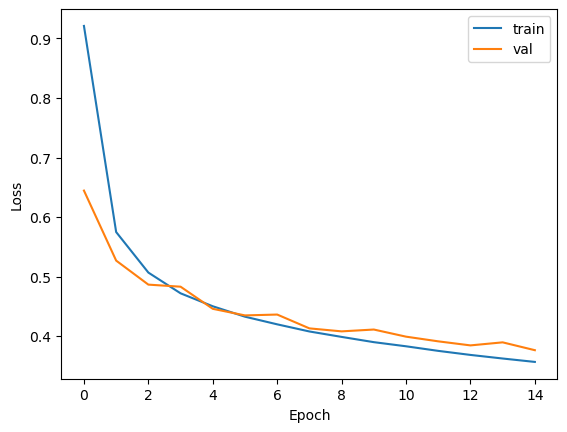

In [53]:
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


model.compile(
    #optimizer='adam',  # TODO: try 'adam'
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

history = model.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    #validation_data=(X_valid, y_valid),
    callbacks=callbacks,
    batch_size=64
)

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Tasks and questions on the MLP

In [54]:
# Start tensorboard as a background task - break it by stopping the kernel
!tensorboard --logdir logs

^C


Open browser to view tensorboard: http://localhost:6006/

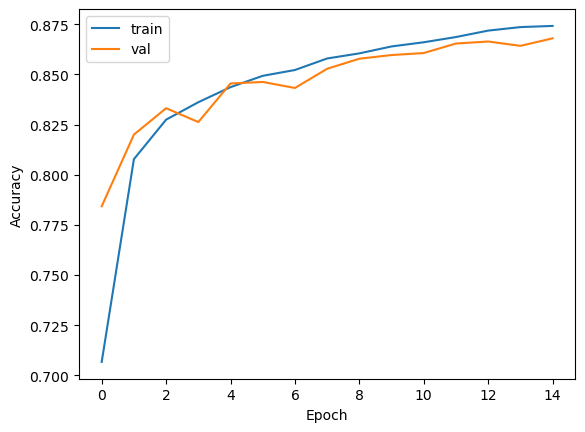

In [55]:
# Accuracy plots
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

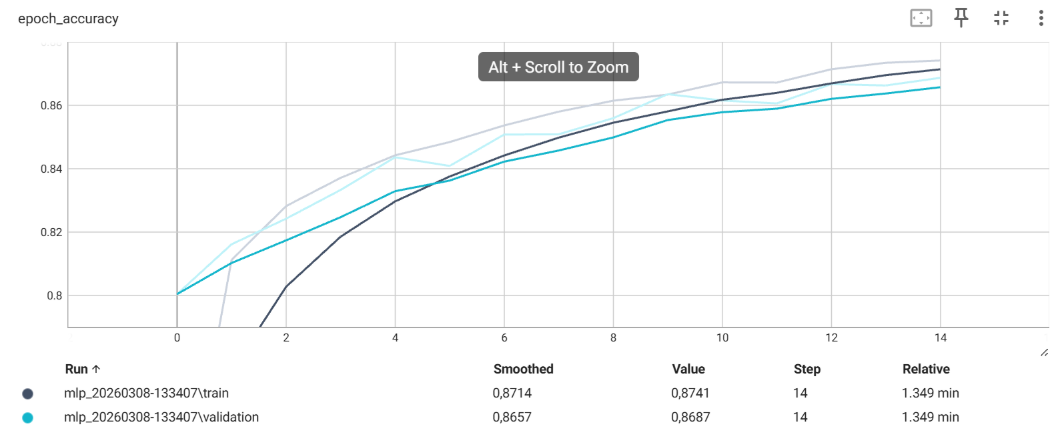
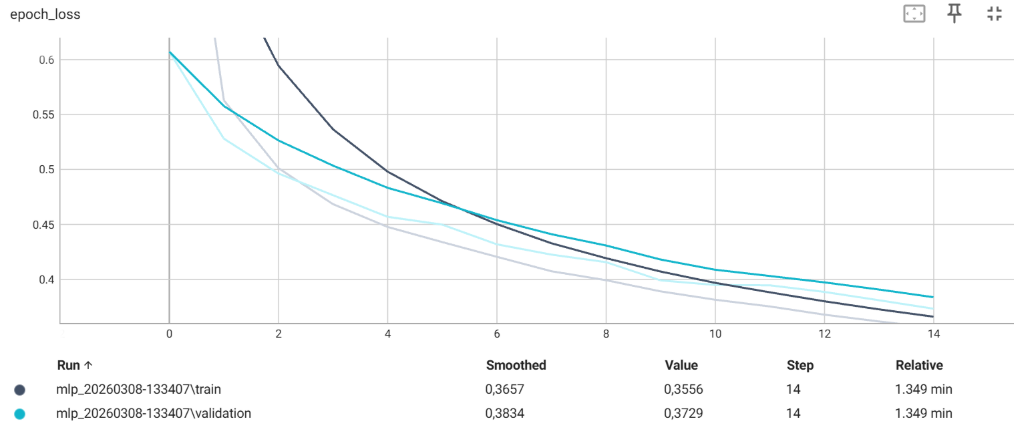

As seen in the screenshots above the the accuracy increases for each epoch wheras the loss decreases for each epoch - as expected.

## Additional Tasks on dataset

For each subtask a new model is created where the given parameter is tweaked - at the end each model is plotted together to show the effect of each parameter.

In [56]:
# Aditional tasks to optimize acc
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout
import tensorflow as tf
import matplotlib.pyplot as plt

### T8.c

In [57]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]

# T8.c - More training Epochs
model_t8c = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_t8c.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8c = model_t8c.fit(
    X_train, y_train,
    epochs=30,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8212 - loss: 0.5064 - val_accuracy: 0.8573 - val_loss: 0.3878
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8658 - loss: 0.3691 - val_accuracy: 0.8669 - val_loss: 0.3610
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8783 - loss: 0.3299 - val_accuracy: 0.8697 - val_loss: 0.3523
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8892 - loss: 0.3036 - val_accuracy: 0.8791 - val_loss: 0.3469
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8937 - loss: 0.2860 - val_accuracy: 0.8856 - val_loss: 0.3290
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8969 - loss: 0.2754 - val_accuracy: 0.8837 - val_loss: 0.3217
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9034 - loss: 0.2573 - val_accuracy: 0.8778 - val_loss: 0.3426
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9063 - loss: 0.2496 - va

### T8.d

In [58]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.d - Add a third hidden layer
model_t8d = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

model_t8d.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8d = model_t8d.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.8162 - loss: 0.5139 - val_accuracy: 0.8493 - val_loss: 0.4150
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - accuracy: 0.8633 - loss: 0.3706 - val_accuracy: 0.8553 - val_loss: 0.3985
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8769 - loss: 0.3332 - val_accuracy: 0.8795 - val_loss: 0.3431
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8860 - loss: 0.3078 - val_accuracy: 0.8742 - val_loss: 0.3419
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8927 - loss: 0.2855 - val_accuracy: 0.8687 - val_loss: 0.3840
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8950 - loss: 0.2782 - val_accuracy: 0.8882 - val_loss: 0.3208
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9040 - loss: 0.2592 - val_accuracy: 0.8786 - val_loss: 0.3430
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9066 - loss: 0.2500 - va

### T8.e

In [59]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.e - Different number of neurons

model_t8e = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(10, activation='softmax')
])

model_t8e.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8e = model_t8e.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.8236 - loss: 0.4859 - val_accuracy: 0.8652 - val_loss: 0.3738
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.8655 - loss: 0.3649 - val_accuracy: 0.8546 - val_loss: 0.3970
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step - accuracy: 0.8791 - loss: 0.3246 - val_accuracy: 0.8769 - val_loss: 0.3415
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8886 - loss: 0.2984 - val_accuracy: 0.8748 - val_loss: 0.3329
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8964 - loss: 0.2791 - val_accuracy: 0.8792 - val_loss: 0.3235
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8995 - loss: 0.2681 - val_accuracy: 0.8832 - val_loss: 0.3301
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.9049 - loss: 0.2528 - val_accuracy: 0.8823 - val_loss: 0.3285
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.9082 - loss: 0.2420 - 

### T8.f

In [60]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.f - Trying other activation functions
model_t8f = Sequential([
    Input(shape=(28, 28)),
    Flatten(),

    # tanh (hyperbolic tangent)
    # - Outputs values between -1 and 1
    # - Centered around zero, which can sometimes help training
    Dense(256, activation='tanh'),

    # ELU (Exponential Linear Unit)
    # - Similar to ReLU but allows small negative outputs
    # - Often improves gradient flow and training stability
    Dense(128, activation='elu'),

    # softmax
    # - Converts outputs into probabilities
    # - Ensures all outputs sum to 1
    Dense(10, activation='softmax')
])

model_t8f.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8f = model_t8f.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.8199 - loss: 0.5003 - val_accuracy: 0.8522 - val_loss: 0.4036
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8620 - loss: 0.3769 - val_accuracy: 0.8651 - val_loss: 0.3701
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8734 - loss: 0.3399 - val_accuracy: 0.8534 - val_loss: 0.3821
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8840 - loss: 0.3119 - val_accuracy: 0.8724 - val_loss: 0.3576
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8876 - loss: 0.2972 - val_accuracy: 0.8797 - val_loss: 0.3245
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8967 - loss: 0.2750 - val_accuracy: 0.8759 - val_loss: 0.3382
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.9005 - loss: 0.2635 - val_accuracy: 0.8813 - val_loss: 0.3413
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9040 - loss: 0.2502 - va

### T8.g

In [61]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.g - Adding drop-out layers
model_t8g = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])

model_t8g.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_t8g = model_t8g.fit(
    X_train, y_train,
    epochs=15,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.7789 - loss: 0.6156 - val_accuracy: 0.8406 - val_loss: 0.4256
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8398 - loss: 0.4397 - val_accuracy: 0.8652 - val_loss: 0.3780
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8529 - loss: 0.4039 - val_accuracy: 0.8661 - val_loss: 0.3704
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8608 - loss: 0.3802 - val_accuracy: 0.8714 - val_loss: 0.3562
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8664 - loss: 0.3640 - val_accuracy: 0.8760 - val_loss: 0.3437
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8725 - loss: 0.3470 - val_accuracy: 0.8667 - val_loss: 0.3568
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8751 - loss: 0.3383 - val_accuracy: 0.8735 - val_loss: 0.3442
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.8779 - loss: 0.3300 - val_

### Comparison

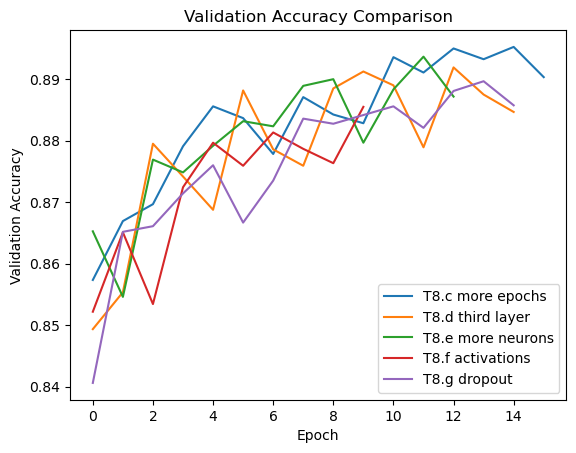

In [62]:
# Compare validation accuracy of all experiments

plt.plot(history_t8c.history['val_accuracy'], label='T8.c more epochs')
plt.plot(history_t8d.history['val_accuracy'], label='T8.d third layer')
plt.plot(history_t8e.history['val_accuracy'], label='T8.e more neurons')
plt.plot(history_t8f.history['val_accuracy'], label='T8.f activations')
plt.plot(history_t8g.history['val_accuracy'], label='T8.g dropout')

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy Comparison')
plt.legend()
plt.show()

### T8.h

In [63]:
# Callbacks
log_dir = "logs/mlp_" + strftime("%Y%m%d-%H%M%S")

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True),
    TensorBoard(log_dir=log_dir)
]
# T8.h - Creating new model and testing on data

# Best MLP model based on the tested parameters

model_best = Sequential([
    Input(shape=(28, 28)),
    Flatten(),

    # Hidden layer 1
    Dense(512, activation='relu'),
    Dropout(0.3),

    # Hidden layer 2
    Dense(256, activation='relu'),
    Dropout(0.3),

    # Hidden layer 3
    Dense(128, activation='relu'),

    # Output layer for 10 classes
    Dense(10, activation='softmax')
])

model_best.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_best = model_best.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    callbacks=callbacks,
    batch_size=64
)

test_loss, test_acc = model_best.evaluate(X_test, y_test)
print("Best model test loss:", test_loss)
print("Best model test accuracy:", test_acc)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.7878 - loss: 0.5844 - val_accuracy: 0.8499 - val_loss: 0.4128
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8411 - loss: 0.4328 - val_accuracy: 0.8647 - val_loss: 0.3722
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8563 - loss: 0.3950 - val_accuracy: 0.8663 - val_loss: 0.3620
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8645 - loss: 0.3722 - val_accuracy: 0.8743 - val_loss: 0.3430
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8701 - loss: 0.3539 - val_accuracy: 0.8728 - val_loss: 0.3452
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 21ms/step - accuracy: 0.8740 - loss: 0.3394 - val_accuracy: 0.8819 - val_loss: 0.3285
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8793 - loss: 0.3301 - val_accuracy: 0.8818 - val_loss: 0.3243
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.8787 - loss: 0.3239 - 

In [66]:
model_best.save("fashion_mnist_best_model.keras")

reloaded_model = tf.keras.models.load_model("fashion_mnist_best_model.keras")

reload_loss, reload_acc = reloaded_model.evaluate(X_test, y_test)
print("----------------------RESULTS----------------------")
print("Reloaded model test loss:", reload_loss)
print("Reloaded model test accuracy:", reload_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8861 - loss: 0.3240
----------------------RESULTS----------------------
Reloaded model test loss: 0.32400330901145935
Reloaded model test accuracy: 0.8860999941825867


### Questions on Model Training

**Q8a:** By temporarily dropping out some of the neurons accuracy will be boosted and the tendency for overfitting is also decreased.

**Q8b:** Overfitting is when the model learns the data too well and thereby includes all the noise in the data. Underfitting is when it is too simple.

**Q8c:** Patience influences the amount of epochs the model will continue training if no change in validation loss has occured.

**Q8d:** If eta is too small the SGD updates the weights too slow and the model will converge to slowly.

**Q8e:** Adam is easier to use as it is an adaptive learning rate algorithm, where SGD uses a constant learning rate. Adam will therefore also converge faster.

**Q8e:** The first layer receives 28 x 28 = 784 inputs and has 256 neurons => (784 x 256) + 256 = 200.960.

**Q8f:** Adam performed better as it converged faster.

**Q8g:** Adding layers increases accuracy but is also computationally heavier.

**Q8h:** Using earlystopping forces the model to break out of training when the validation loss doesnt improve - this prevents the model of learning specific patterns that might cause it to overfit.

**Q8i:** Adding dropout (purple line) had the biggest immediate impact. But overall they all contribute to a higher accuracy.